<a href="https://colab.research.google.com/github/EstelleCNB/xaiproject/blob/main/XAIproject_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparison Of SHAP and LIME Stability on MIT-BIH Heartbeat Signals

Estelle Bennet, Emily Wagner, Yudith Vazquez-Jacinto

In [3]:
!pip install wfdb numpy matplotlib pandas

In [4]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
mount = '/content/drive'
from google.colab import drive
drive.mount(mount)


Mounted at /content/drive


.dat - the raw signal file
- this is the actual ECG record -- the electrical signal capture from the patient's heart over time.

.hea - the header file
- this is the small text file the describes the recording
- tells us things like how many signals are there, the sampling frequency, how long the recording is, the patient id, and the units of measurement
= this is instruction manual for reading the .dat file, wfdb reads this automatically behind the scens when you load a recording

.atr - the annotation file
- it contains the beat lables.
- for every heartbeat in the recording, it stores the exact sample number where the R-peak occurs and the annotation code.



Annotation Code:

Code		Description

N		Normal beat (displayed as "·" by the PhysioBank ATM, LightWAVE, pschart, and psfd)

L		Left bundle branch block beat

R		Right bundle branch block beat

B		Bundle branch block beat (unspecified)

A		Atrial premature beat

a		Aberrated atrial premature beat

J		Nodal (junctional) premature beat

S		Supraventricular premature or ectopic beat (atrial or nodal)

V		Premature ventricular contraction

r		R-on-T premature ventricular contraction

F		Fusion of ventricular and normal beat

e		Atrial escape beat

j		Nodal (junctional) escape beat

n		Supraventricular escape beat (atrial or nodal)

E		Ventricular escape beat

/		Paced beat

f		Fusion of paced and normal beat

Q		Unclassifiable beat

?		Beat not classified during learning




Non-beat annotations:

Code		Description

[		Start of ventricular flutter/fibrillation

!		Ventricular flutter wave

]		End of ventricular flutter/fibrillation

x		Non-conducted P-wave (blocked APC)

(		Waveform onset

)		Waveform end

p		Peak of P-wave

t		Peak of T-wave

u		Peak of U-wave

`		PQ junction

'		J-point

^		(Non-captured)
pacemaker artifact

|		Isolated QRS-like artifact [1]

~		Change in signal quality [1]

+		Rhythm change [2]

s		ST segment change [2]

T		T-wave change [2]

*		Systole

D		Diastole

=		Measurement annotation [2]

"		Comment annotation [2]

@		Link to external data
 [3]


To explain the MIT-BIH Arrhythmia Database, it contains 48 30 minute excerpts of ambulatory ECG recordings from 47 patients. The samples come from a mix of inpatient and outpatients.

To begin our experiment, we first need to import our heartbeat signals and annotation symbols.

['MLII', 'V5'] are 2 different channels used to analyze a specific region of the heart

the bottom row is the annotation for the beat. all N's show this beat was declared as 'Normal'

Signal Preprocessing & Cleaning:

1) Importing the MIT-BIH Arrhythmia Database and Plotting Sample Beats

In [5]:
data_path = '/content/drive/MyDrive/xAI project/mit-bit-dataset'

record = wfdb.rdrecord(data_path + '/100') #record the actual data for heartbeat 100
annotation = wfdb.rdann(data_path + '/100', 'atr') #record the annotation for beat 100

print(record.sig_name)
print(annotation.symbol)

['MLII', 'V5']
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N',

This is a graph of the first 10 seconds of a sample beat.

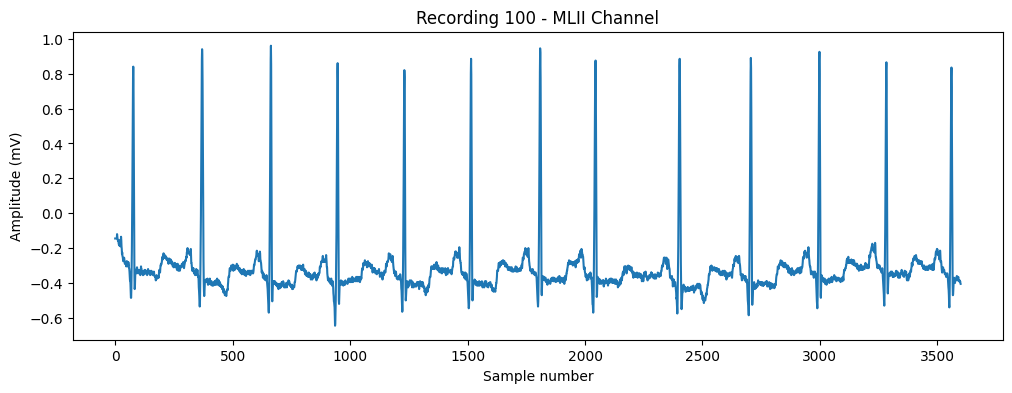

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(record.p_signal[:3600, 0])  # channel 0 = MLII
plt.title('Recording 100 - MLII Channel')
plt.xlabel('Sample number')
plt.ylabel('Amplitude (mV)')
plt.show() #this plots the first ten seconds of the signal: 360 signals per second * 10 = 3600

Now, we want to confirm that the annotations align with the R-peaks (the sharp spikes) in the signal.

The graph below shows a peak around 70 and 370 which matches the below list detailing the indexes where an R peak occurs.

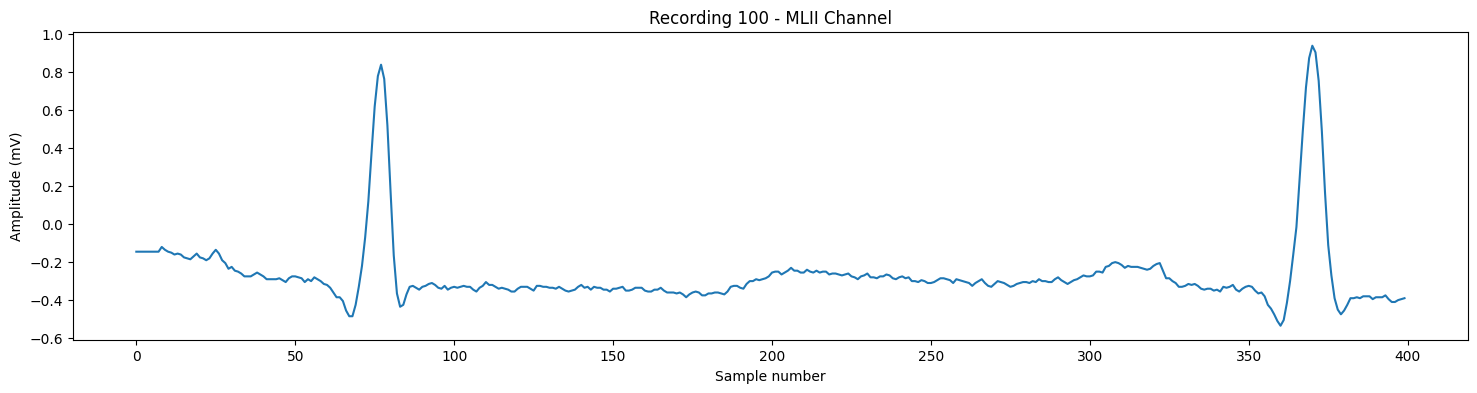

In [7]:
plt.figure(figsize=(18, 4))
plt.plot(record.p_signal[:400, 0])  # channel 0 = MLII
plt.title('Recording 100 - MLII Channel')
plt.xlabel('Sample number')
plt.ylabel('Amplitude (mV)')
plt.show() #this plots the first ten seconds of the signal: 360 signals per second * 10 = 3600

In [8]:
print(annotation.sample)

[    18     77    370 ... 649484 649734 649991]


This output above means that the first beat occurs at sample 77, then the second at sample 370. The 18 shows where the rhythm starts.

This confirms our annotations and R-peaks align.

This is further code to visually confirm R-Peaks and their respective indexes align.

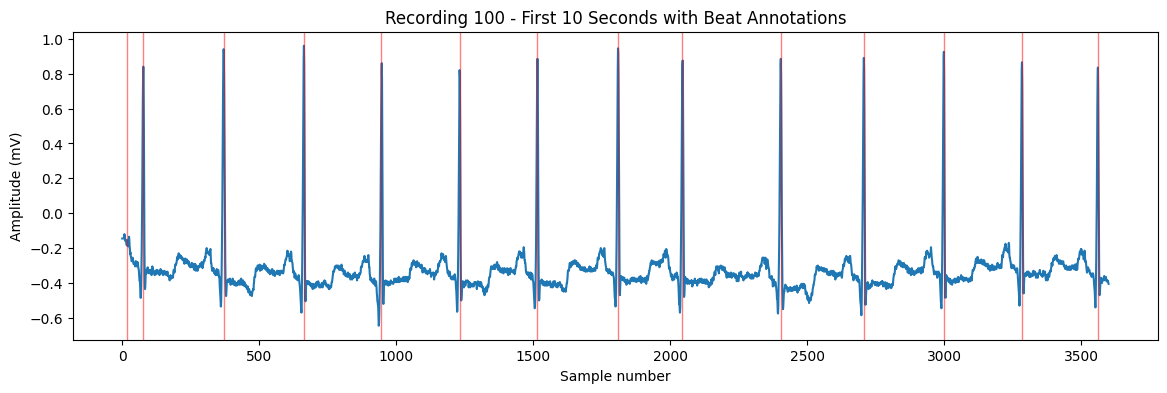

In [9]:
window = 3600

annotation_samples = annotation.sample[annotation.sample < window]  #this filters the annoations to only include those that occur within the first 10 seconds of the signal
signal_window = record.p_signal[:window, 0] #this gets the first 10 seconds of the signal for channel 0 (MLII)

plt.figure(figsize=(14, 4))
plt.plot(signal_window)

for sample in annotation_samples:
    plt.axvline(x=sample, color='red', alpha=0.5, linewidth=1)

plt.title('Recording 100 - First 10 Seconds with Beat Annotations')
plt.xlabel('Sample number')
plt.ylabel('Amplitude (mV)')
plt.show()

The red lines on the sharp spikes show that the annotations are aligned correctly.


In [10]:
window_before = 90
window_after = 90
window_size = window_before + window_after

A heartbeat is a combination of the P-wave, which captures the upper chamber of the heart, the QRS complex which is the spike captured by the lower heart chambers, and lastly the T-wave which captures the heart recovering after the beat or resting.



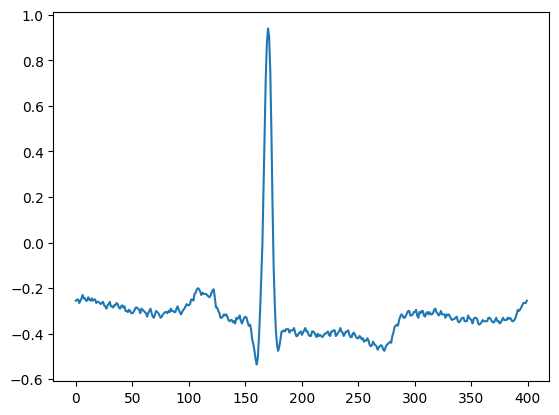

In [11]:
plt.plot(record.p_signal[200:600, 0]) #this is what the entire heartbeat looks like
plt.show()

Signal Preprocessing & Cleaning:

  2) Extracting all of the hearbeats.

Here, we are going through the above sample heartbeat, sample 100, and extracting all of the beats and labels for that beat around a fixed window. The window we choose is 180 samples.

In [12]:
beats = []  # this will store the signal windows
labels = []  # this will store the beat labels
metadata = []  # this will store patient info

for i, sample in enumerate(annotation.sample):
    # this define the start and end of the window
    start = sample - window_before
    end = sample + window_after

    # extract the window from the signal
    beat = record.p_signal[start:end, 0]

    beats.append(beat)
    labels.append(annotation.symbol[i])

This is extra code to handle edge cases such as if a sample is to close to the start or end of the recording.

In [13]:
for i, sample in enumerate(annotation.sample):
    start = sample - window_before
    end = sample + window_after

    # Edge case 1: beat too close to start or end of recording
    if start < 0 or end > len(record.p_signal):
        continue  # skip this beat

    # Edge case 2: window is wrong size (corrupted signal)
    beat = record.p_signal[start:end, 0]
    if len(beat) != window_size:
        continue  # skip this beat

    beats.append(beat)
    labels.append(annotation.symbol[i])

We defined a function to map labels with annotations that signify if a beat is normal or arrhythmic.

In [14]:
def map_label(symbol):
    """
    Maps MIT-BIH annotation symbols to binary labels.
    Returns 0 for Normal, 1 for Abnormal, None to skip.
    """
    normal_beats = ['N', 'L', 'R', 'e', 'j']          # Normal-class beats
    abnormal_beats = ['V', 'F', 'f', '!', 'E',         # Ventricular
                      'A', 'a', 'J', 'S',                # Supraventricular
                      'P', '/', 'Q', 'q']               # Paced / unclassified

    if symbol in normal_beats:
        return 0
    elif symbol in abnormal_beats:
        return 1
    else:
        return None  # Skip the ambiguous or non-beat annotations

Extending our above code to all of the dataset, we are now extracting all heartbeats and labels.

In [15]:
# All MIT-BIH recording numbers
record_names = [
    '100', '101', '102', '103', '104', '105', '106', '107',
    '108', '109', '111', '112', '113', '114', '115', '116',
    '117', '118', '119', '121', '122', '123', '124', '200',
    '201', '202', '203', '205', '207', '208', '209', '210',
    '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

all_beats = []
all_labels = []
all_metadata = []

for rec_name in record_names:
    try:
        record = wfdb.rdrecord(data_path + '/' + rec_name)
        annotation = wfdb.rdann(data_path + '/' + rec_name, 'atr')

        print(f'Processing recording {rec_name}...')

        for i, sample in enumerate(annotation.sample):
            start = sample - window_before
            end = sample + window_after

            if start < 0 or end > len(record.p_signal):
                continue

            beat = record.p_signal[start:end, 0]
            if len(beat) != window_size:
                continue

            label = map_label(annotation.symbol[i])
            if label is None:
                continue

            all_beats.append(beat)
            all_labels.append(label)
            all_metadata.append({
                'patient_id': rec_name,
                'sample_index': sample,
                'original_label': annotation.symbol[i],
                'binary_label': label
            })

    except Exception as e:
        print(f'Skipping {rec_name}: {e}')

print(f'Total beats extracted: {len(all_beats)}')

Processing recording 100...
Processing recording 101...
Processing recording 102...
Processing recording 103...
Processing recording 104...
Processing recording 105...
Processing recording 106...
Processing recording 107...
Processing recording 108...
Processing recording 109...
Processing recording 111...
Processing recording 112...
Processing recording 113...
Processing recording 114...
Processing recording 115...
Processing recording 116...
Processing recording 117...
Processing recording 118...
Processing recording 119...
Processing recording 121...
Processing recording 122...
Processing recording 123...
Processing recording 124...
Processing recording 200...
Processing recording 201...
Processing recording 202...
Processing recording 203...
Processing recording 205...
Processing recording 207...
Processing recording 208...
Processing recording 209...
Processing recording 210...
Processing recording 212...
Processing recording 213...
Processing recording 214...
Processing recording

Once we have extracted our hearbeat sample windows, we now are converting to a numpy array for machine learning analysis.

In [16]:
import numpy as np
import pandas as pd

# Convert to numpy arrays
beats_array = np.array(all_beats)
labels_array = np.array(all_labels)
metadata_df = pd.DataFrame(all_metadata)

# Save to data path
np.save(f'{data_path}/beats.npy', beats_array)
np.save(f'{data_path}/labels.npy', labels_array)
metadata_df.to_csv(f'{data_path}/metadata.csv', index=False)

print(f'Beats array shape: {beats_array.shape}')
print(f'Labels array shape: {labels_array.shape}')
print('Files saved successfully')

Beats array shape: (109940, 180)
Labels array shape: (109940,)
Files saved successfully


After extracting our heartbeats, we wanted to see the distribution of normal and arrythmic heartbeats to determine if there is a class imbalance.

Class distribution:
Normal beats (0): 90608
Arrhythmic beats (1): 19332


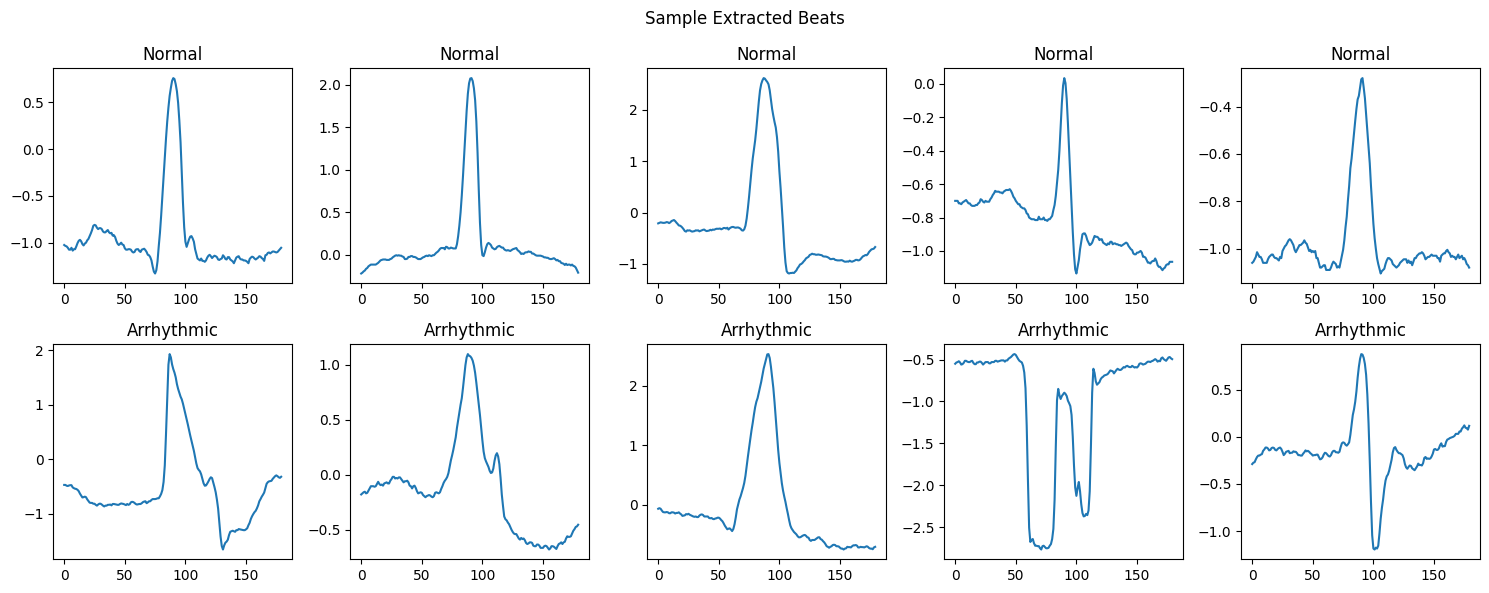

In [17]:
import random

# Print class distribution
unique, counts = np.unique(labels_array, return_counts=True)
print('Class distribution:')
print(f'Normal beats (0): {counts[0]}')
print(f'Arrhythmic beats (1): {counts[1]}')

# Plot 5 random normal beats and 5 random arrhythmic beats
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Extracted Beats')

normal_indices = np.where(labels_array == 0)[0]
arrhythmic_indices = np.where(labels_array == 1)[0]

for i in range(5):
    # Plot a random normal beat on top row
    idx = random.choice(normal_indices)
    axes[0, i].plot(beats_array[idx])
    axes[0, i].set_title('Normal')

    # Plot a random arrhythmic beat on bottom row
    idx = random.choice(arrhythmic_indices)
    axes[1, i].plot(beats_array[idx])
    axes[1, i].set_title('Arrhythmic')

plt.tight_layout()
plt.show()

import random
import string
import numpy as np
import matplotlib.pyplot as plt

Signal Preprocessing & Cleaning

3) Clean and normalize raw heartbeat signals into a format conducive for testing

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import random
import numpy as np
from scipy import signal

Here, we are making a copy of our beats array to preserve the original heartbeat array. After plotting we see 180 data points representing the voltage of the heartbeat at a specific time.

In [19]:
#makes a copy of beats_array
copy_beats_array = list(beats_array)
print(copy_beats_array[2])


[-0.375 -0.385 -0.355 -0.36  -0.355 -0.36  -0.36  -0.37  -0.36  -0.345
 -0.355 -0.345 -0.345 -0.345 -0.34  -0.31  -0.305 -0.305 -0.31  -0.305
 -0.29  -0.285 -0.275 -0.28  -0.28  -0.275 -0.265 -0.255 -0.245 -0.26
 -0.265 -0.275 -0.28  -0.265 -0.27  -0.275 -0.28  -0.275 -0.28  -0.275
 -0.265 -0.255 -0.24  -0.26  -0.28  -0.31  -0.31  -0.345 -0.36  -0.38
 -0.385 -0.38  -0.37  -0.375 -0.385 -0.39  -0.395 -0.385 -0.385 -0.385
 -0.395 -0.405 -0.4   -0.375 -0.375 -0.39  -0.395 -0.415 -0.405 -0.4
 -0.39  -0.405 -0.425 -0.46  -0.475 -0.505 -0.51  -0.525 -0.54  -0.6
 -0.645 -0.63  -0.575 -0.495 -0.385 -0.27  -0.115  0.09   0.37   0.635
  0.81   0.86   0.77   0.475  0.065 -0.305 -0.5   -0.52  -0.475 -0.41
 -0.39  -0.39  -0.4   -0.41  -0.405 -0.385 -0.39  -0.395 -0.405 -0.41
 -0.405 -0.4   -0.39  -0.395 -0.41  -0.415 -0.41  -0.395 -0.405 -0.41
 -0.405 -0.405 -0.41  -0.39  -0.385 -0.39  -0.395 -0.4   -0.4   -0.4
 -0.395 -0.395 -0.405 -0.405 -0.4   -0.395 -0.385 -0.375 -0.385 -0.395
 -0.39  -0.385 -0

Now we are plotting several raw signals to build intuition for what noise looks like.

Text(0.5, 1.0, 'Sample 33462')

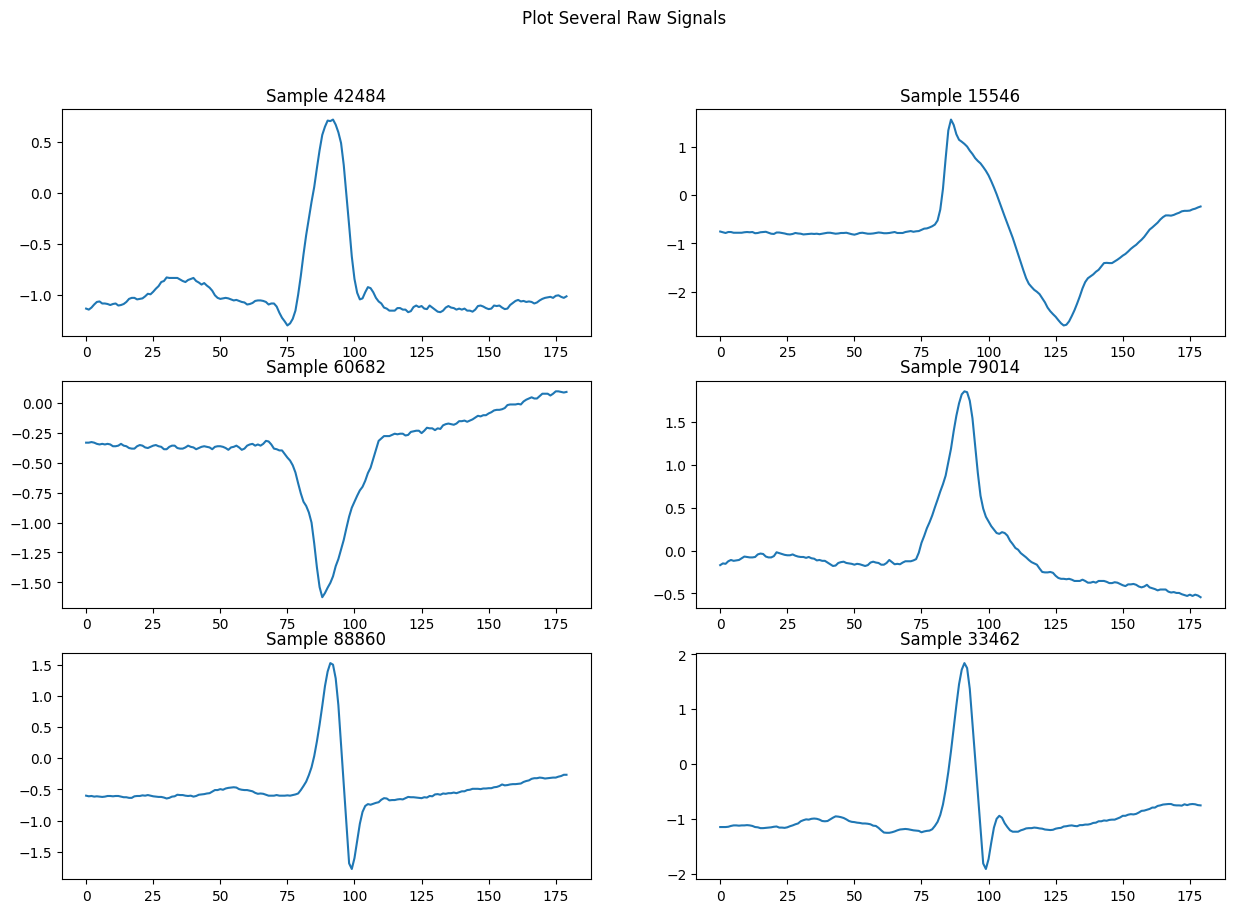

In [20]:
fig, ax = plt.subplots(3,2, figsize=(15,10))
fig.suptitle("Plot Several Raw Signals")


rand_sample1 = random.randint(0,109940)
ax[0,0].plot(copy_beats_array[rand_sample1])
ax[0,0].set_title(f"Sample {rand_sample1}")


rand_sample2 = random.randint(0,109940)
ax[0,1].plot(copy_beats_array[rand_sample2])
ax[0,1].set_title(f"Sample {rand_sample2}")


rand_sample3 = random.randint(0,109940)
ax[1,0].plot(copy_beats_array[rand_sample3])
ax[1,0].set_title(f"Sample {rand_sample3}")


rand_sample4 = random.randint(0,109940)
ax[1,1].plot(copy_beats_array[rand_sample4])
ax[1,1].set_title(f"Sample {rand_sample4}")

rand_sample5 = random.randint(0,109940)
ax[2,0].plot(copy_beats_array[rand_sample5])
ax[2,0].set_title(f"Sample {rand_sample5}")

rand_sample6 = random.randint(0,109940)
ax[2,1].plot(copy_beats_array[rand_sample6])
ax[2,1].set_title(f"Sample {rand_sample6}")

Overall, we can see jagged, non smooth regions on the length of the wave. Ideally, we will perform testing on signals that are normalized and processed so high and low frequency noise are removed.


Now we implement baseline wander removal to clean the signal and remove low-frequency noise using a high-pass filter.

Baseline wander is when the baseline shifts up and down due to the patient moving or breathing. This can add noise typically below 0.5 HZ that can cause an inaccurate reading of the ECG.

Text(0.5, 1.0, 'Sample 33462')

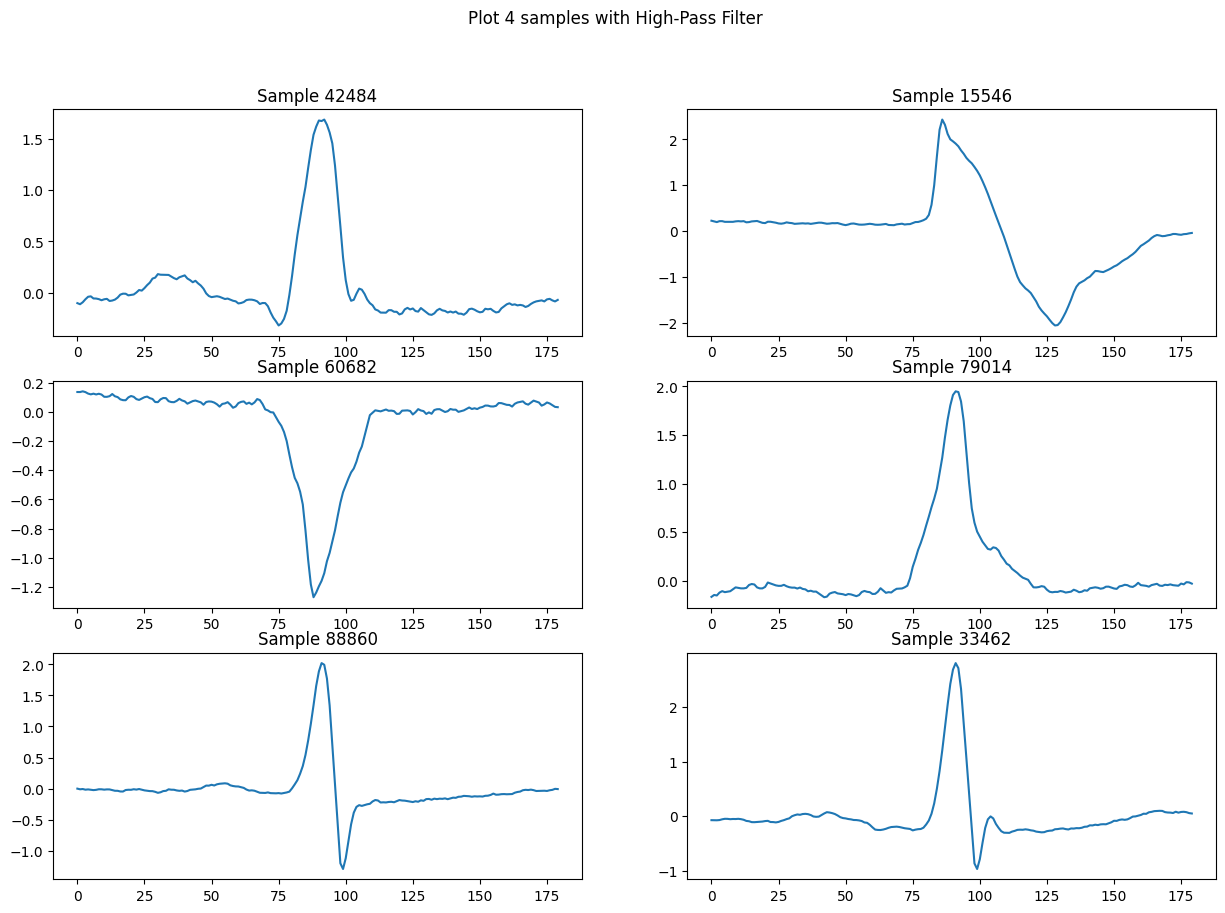

In [21]:
#use filter to remove low frequencies
def butter_highpass_filter(data, cutoff, fs, order):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq

    b,a = signal.butter(order, normal_cutoff, btype='high', analog=False)

    filtered_data = signal.filtfilt(b, a, data, axis =0)
    return filtered_data

#specify frequency for data
fs = 360
cutoff_frequency = 0.5
filter_order = 3

#create 6 filtered signals of 4 random heartbeat samples
highpass_filtered_signal1 = butter_highpass_filter(copy_beats_array[rand_sample1], cutoff_frequency, fs, filter_order)
highpass_filtered_signal2 = butter_highpass_filter(copy_beats_array[rand_sample2], cutoff_frequency, fs, filter_order)
highpass_filtered_signal3 = butter_highpass_filter(copy_beats_array[rand_sample3], cutoff_frequency, fs, filter_order)
highpass_filtered_signal4 = butter_highpass_filter(copy_beats_array[rand_sample4], cutoff_frequency, fs, filter_order)
highpass_filtered_signal5 = butter_highpass_filter(copy_beats_array[rand_sample5], cutoff_frequency, fs, filter_order)
highpass_filtered_signal6 = butter_highpass_filter(copy_beats_array[rand_sample6], cutoff_frequency, fs, filter_order)

#plot the signals with highpass filter applied
fig, ax = plt.subplots(3,2, figsize=(15,10))
fig.suptitle("Plot 4 samples with High-Pass Filter")

#Plot 4 sample graphs with examples from previous tab
ax[0,0].plot(highpass_filtered_signal1)
ax[0,0].set_title(f"Sample {rand_sample1}")

ax[0,1].plot(highpass_filtered_signal2)
ax[0,1].set_title(f"Sample {rand_sample2}")

ax[1,0].plot(highpass_filtered_signal3)
ax[1,0].set_title(f"Sample {rand_sample3}")

ax[1,1].plot(highpass_filtered_signal4)
ax[1,1].set_title(f"Sample {rand_sample4}")

ax[2,0].plot(highpass_filtered_signal5)
ax[2,0].set_title(f"Sample {rand_sample5}")

ax[2,1].plot(highpass_filtered_signal6)
ax[2,1].set_title(f"Sample {rand_sample6}")


Here, we are implementing high-frequency noise removal using a low-pass filter
and plotting before/after to confirm signals are smoother but not distorted.


Text(0.5, 1.0, 'Sample 33462')

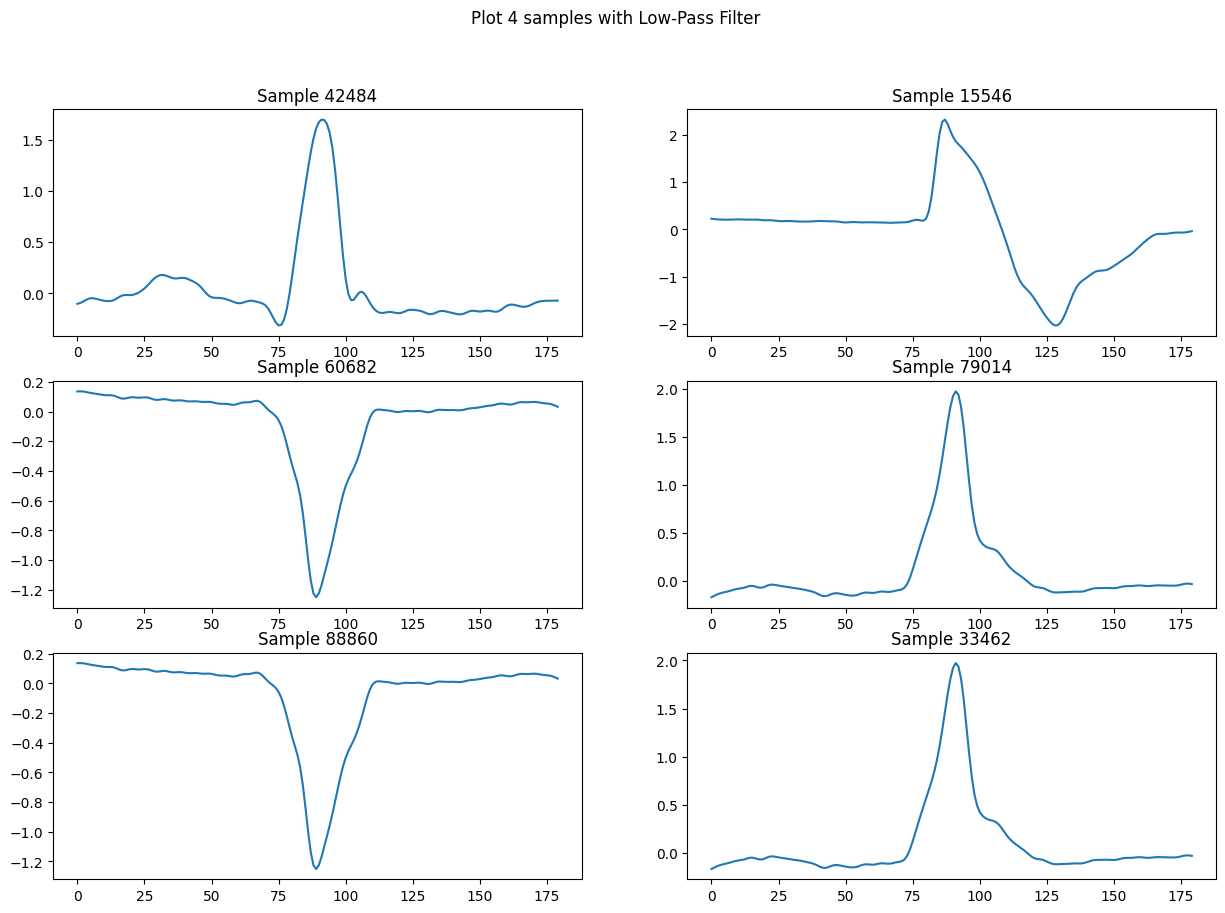

In [22]:
#low pass filter
def butter_low_pass_filter(data, cutoff, fs, order):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    d, c = signal.butter(order, normal_cutoff, btype='low')
    filtered_data_ = signal.filtfilt(d, c, data, axis = 0)
    return filtered_data_

cutoff_freq = 50
fs = 360
filter_order = 3

#create 4 filtered signals of 4 random heartbeat samples
filtered_signal_highpass_lowpass1 = butter_low_pass_filter(highpass_filtered_signal1, cutoff_freq, fs, filter_order)
filtered_signal_highpass_lowpass2 = butter_low_pass_filter(highpass_filtered_signal2, cutoff_freq, fs, filter_order)
filtered_signal_highpass_lowpass3 = butter_low_pass_filter(highpass_filtered_signal3, cutoff_freq, fs, filter_order)
filtered_signal_highpass_lowpass4 = butter_low_pass_filter(highpass_filtered_signal4, cutoff_freq, fs, filter_order)
filtered_signal_highpass_lowpass5 = butter_low_pass_filter(highpass_filtered_signal5, cutoff_freq, fs, filter_order)
filtered_signal_highpass_lowpass6 = butter_low_pass_filter(highpass_filtered_signal6, cutoff_freq, fs, filter_order)

fig, ax = plt.subplots(3,2, figsize=(15,10))
fig.suptitle("Plot 4 samples with Low-Pass Filter")

#Plot 4 sample graphs with examples from previous tab
ax[0,0].plot(filtered_signal_highpass_lowpass1)
ax[0,0].set_title(f"Sample {rand_sample1}")

ax[0,1].plot(filtered_signal_highpass_lowpass2)
ax[0,1].set_title(f"Sample {rand_sample2}")

ax[1,0].plot(filtered_signal_highpass_lowpass3)
ax[1,0].set_title(f"Sample {rand_sample3}")

ax[1,1].plot(filtered_signal_highpass_lowpass4)
ax[1,1].set_title(f"Sample {rand_sample4}")

ax[2,0].plot(filtered_signal_highpass_lowpass3)
ax[2,0].set_title(f"Sample {rand_sample5}")

ax[2,1].plot(filtered_signal_highpass_lowpass4)
ax[2,1].set_title(f"Sample {rand_sample6}")

These two filters have produced a much smoother signal all around. Lastly, we will need to normalize the signals. This is because different heartbeat signals may have a different baseline. We want our models to learn insights from the heartbeat signals overall and normalizing the signals helps the ml models not become confused by slight differences in the heartbeat derived from issues like how the electrode nodes were placed on someone's skin or other noise.

Next, we are implementing z-score normalization on each beat window.
    We want to to make every beat have a mean of 0 and a std dev of 1.

Text(0.5, 1.0, 'Sample 33462')

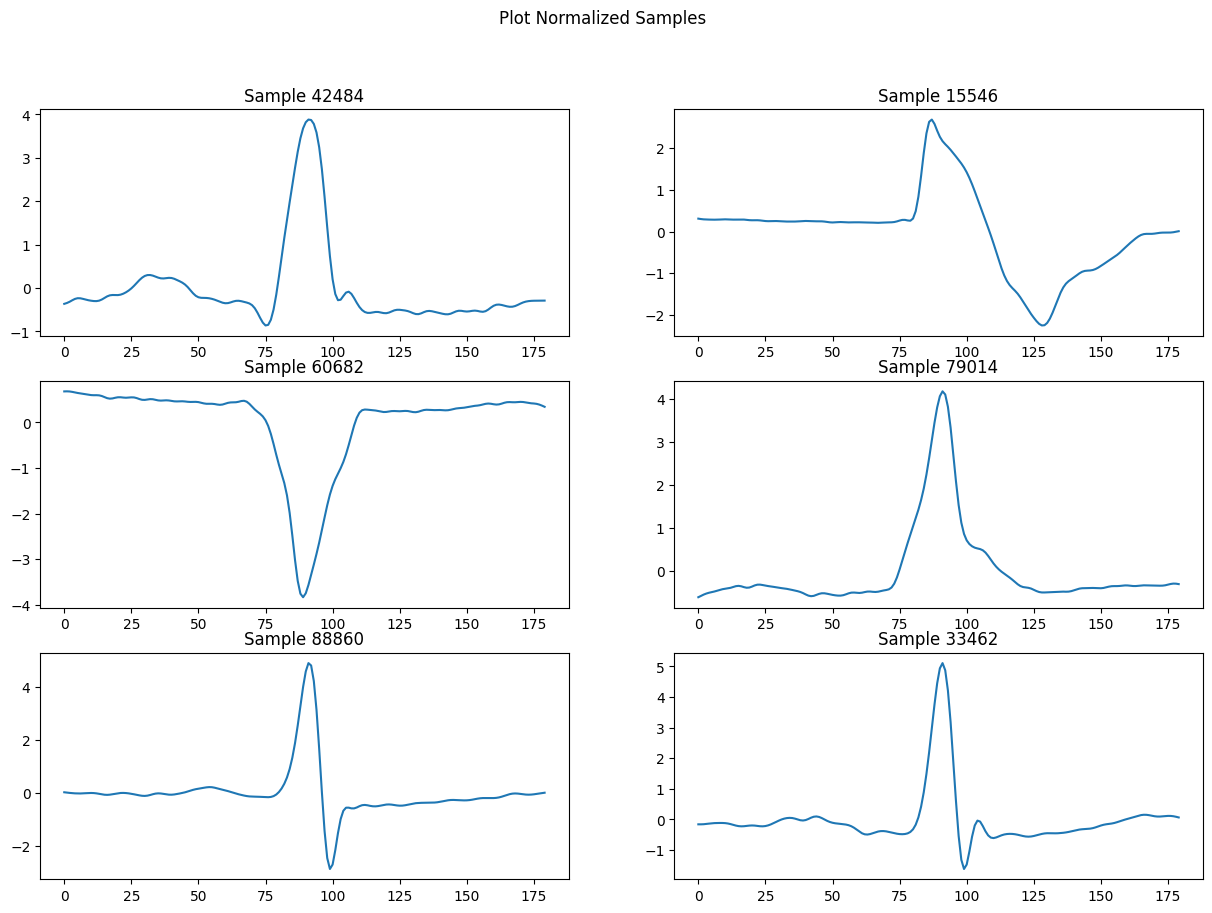

In [23]:
#this normalize function takes an array of data
def z_score_normalize(data):
    #takes mean and std dev of data
    mu = np.mean(data)
    sigma = np.std(data)

    normalized = (data - mu) / sigma

    return normalized

#create 6 normalized signals
normalized_sig1 = z_score_normalize(filtered_signal_highpass_lowpass1)
normalized_sig2 = z_score_normalize(filtered_signal_highpass_lowpass2)
normalized_sig3 = z_score_normalize(filtered_signal_highpass_lowpass3)
normalized_sig4 = z_score_normalize(filtered_signal_highpass_lowpass4)
normalized_sig5 = z_score_normalize(filtered_signal_highpass_lowpass5)
normalized_sig6 = z_score_normalize(filtered_signal_highpass_lowpass6)

#Plot 6 normalized sample graphs
fig, ax = plt.subplots(3,2, figsize=(15,10))
fig.suptitle("Plot Normalized Samples")

ax[0,0].plot(normalized_sig1)
ax[0,0].set_title(f"Sample {rand_sample1}")

ax[0,1].plot(normalized_sig2)
ax[0,1].set_title(f"Sample {rand_sample2}")

ax[1,0].plot(normalized_sig3)
ax[1,0].set_title(f"Sample {rand_sample3}")

ax[1,1].plot(normalized_sig4)
ax[1,1].set_title(f"Sample {rand_sample4}")

ax[2,0].plot(normalized_sig5)
ax[2,0].set_title(f"Sample {rand_sample5}")

ax[2,1].plot(normalized_sig6)
ax[2,1].set_title(f"Sample {rand_sample6}")



Now we are creating a pipeline function to clean all beats.


In [24]:
def clean_data(data):
    #make new array for cleaned data
    cleaned_processed_signals = []

    #make array for grabage beats
    flagged = []
    flagged_details = []
    for i in range(len(data)):
        #take 1 individual unprocessed heartbeat signal
        ind_signal = data[i]
        try:
          #check for flatlines
          if np.std(ind_signal) < 0.002:
            flagged.append(i)
            flagged_details.append(f'Beat {i} Flatline or noisy signal')
            continue
          #check if signal has naan values
          if np.isnan(ind_signal).any() == True:
            flagged.append(i)
            flagged_details.append(f'Beat {i} nan value found')
            continue
          if np.max(ind_signal) > 6 or np.min(ind_signal) < -6:
            flagged.append(i)
            flagged_details.append(f'Beat {i} range invalid')
            continue

          #apply filters and normalization function
          applied_highpass_ind = butter_highpass_filter(ind_signal, 0.5, 360, 3)
          applied_lowpass_ind = butter_low_pass_filter(applied_highpass_ind, 50, 360, 3)
          applied_normalization_ind = z_score_normalize(applied_lowpass_ind)


          #append cleaned data to new array
          cleaned_processed_signals.append(applied_normalization_ind)

        except:
          print(f"Error with beat {i}, skipping")
          continue

    cleaned_processed_np_arr = np.array(cleaned_processed_signals)
    print(f"Cleaned data shape: {cleaned_processed_np_arr.shape}")
    print(f"Flagged beats: {len(flagged)}")
    return cleaned_processed_np_arr, flagged, flagged_details

cleaned_beat_signals, bad_signals, flagged_details = clean_data(copy_beats_array)




Cleaned data shape: (109940, 180)
Flagged beats: 0


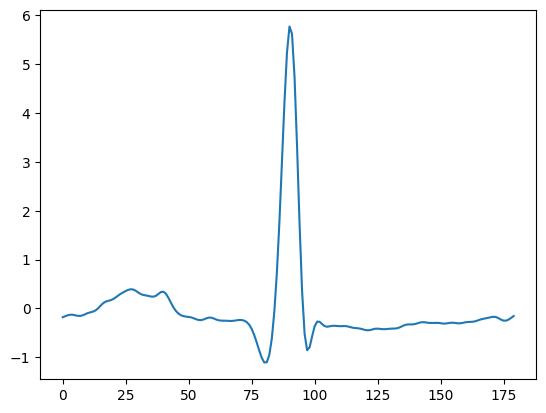

In [25]:
#plot cleaned data sample point
plt.plot(cleaned_beat_signals[5])


We see a smoother signal here and a normalized amplitude.

In [26]:

#save cleaned data #edited 4/10/26
save_path = "/content/drive/MyDrive/xAI project"
np.save(f'{save_path}/cleaned_beat_signals.npy', cleaned_beat_signals)


#use this command to open
#data = np.load('cleaned_beat_signals.npy')

Signal Preprocessing & Cleaning:

 4) Data Splitting & Visualization
 At this point in our experiment, we have extracted all of our hearbeat signals and labels. We have processed our signals by normalizing them and removing low and high fequency noise. We will now split this data into training, test, and validation arrays before finally training our ml models.

We are splitting  at the patient level rather than the beat level to prevent data leakage and ensure that the model is evaluated fairly.

Each patient’s ECG recording contains many individual heartbeats that has different characteristics, such as signal patterns, noise structure, and physiological traits.

If the data were split at the beat level, it is very likely that beats from the same patient would appear in both the training and testing sets. In this case, the model would effectively “see” very similar data during training and testing,*allowing it to memorize patient-specific features rather than learn general patterns of arrhythmia.

This would lead to artificially high performance metrics that do not reflect how the model would perform on completely new patients.

By splitting at the patient level, all beats from a single patient are assigned to only one dataset (training, validation, or testing). This forces the model to learn patterns that generalize across different individuals, rather than relying on patient-specific information.

As a result, the evaluation more accurately represents real-world performance, where the model must analyze ECG data from patients it has never encountered before.

In [27]:
pip install numpy pandas matplotlib scikit-learn

In [28]:
from google.colab import drive
drive.mount('/content/drive')

#load cleaned arrays and metadata CSV
import numpy as np
import pandas as pd

base_path = "/content/drive/MyDrive/xAI project"
cleaned_path = f"{base_path}/cleaned_beat_signals.npy"
metadata_path = f"{base_path}/mit-bit-dataset/metadata.csv"

# Load files
X = np.load(cleaned_path)
meta = pd.read_csv(metadata_path)

# Check
print("X shape:", X.shape)
print("Meta shape:", meta.shape)
print(meta.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X shape: (109940, 180)
Meta shape: (109940, 4)
   patient_id  sample_index original_label  binary_label
0         100           370              N             0
1         100           662              N             0
2         100           946              N             0
3         100          1231              N             0
4         100          1515              N             0


We see above the first 4 rows of the metadata showing the relationship between each heartbeat and patient. This allows us to see which heartbeats belong to which patient, enabling us to adequetely split out heartbeat signals at the patient level.

In [29]:
#list of unique patient IDS from the metadata CSV
patient_ids = meta["patient_id"].unique()
print("Number of unique patients:", len(patient_ids))
print("Unique patient IDs:")
print(patient_ids)


Number of unique patients: 48
Unique patient IDs:
[100 101 102 103 104 105 106 107 108 109 111 112 113 114 115 116 117 118
 119 121 122 123 124 200 201 202 203 205 207 208 209 210 212 213 214 215
 217 219 220 221 222 223 228 230 231 232 233 234]


Further, we are generating a list of all unique patients to also make sure our ml model is only gaining insights at the patient level to prevent data leakage.

In [30]:
#patient level summary for stratified split
patient_summary = (
    meta.groupby("patient_id")
    .agg(
        total_beats=("binary_label", "size"),
        arrhythmia_count=("binary_label", "sum")
    )
    .reset_index()
)

patient_summary["arrhythmia_fraction"] = (
    patient_summary["arrhythmia_count"] / patient_summary["total_beats"]
)
# 0 = mostly normal patient
# 1 = mostly arrhythmic patient
patient_summary["strat_bin"] = (
    patient_summary["arrhythmia_fraction"] >= 0.5
).astype(int)

print("\nPatient summary:")
print(patient_summary.head())

print("\nStratification counts:")
print(patient_summary["strat_bin"].value_counts())



Patient summary:
   patient_id  total_beats  arrhythmia_count  arrhythmia_fraction  strat_bin
0         100         2271                34             0.014971          0
1         101         1864                 5             0.002682          0
2         102         2187              2088             0.954733          1
3         103         2084                 2             0.000960          0
4         104         2228              2065             0.926840          1

Stratification counts:
strat_bin
0    43
1     5
Name: count, dtype: int64


We are showing total beats per patient as well as how many arrhythmias they had. We are stratifying the patients into 2 different bins such that if they had more normal beats they are in class 0 and if they had more abnormal beats they are in class 1. We are doing this to make sure that the patients are relatively evenly split between groups.

We will pass this strat bin when spliting our data into training, testing, and validation. We want to make sure that each set has a similar ratio of normal and arrhythmic heartbeats.

In [31]:
from sklearn.model_selection import train_test_split

#split patient IDs into train, validation, and test groups 33/7/8

train_patients, temp_patients = train_test_split(
    patient_summary,
    test_size=0.30,
    random_state=42,
    stratify=patient_summary["strat_bin"]
)

temp_bin_counts = temp_patients["strat_bin"].value_counts()
print("\nTemp stratification counts:")
print(temp_bin_counts)

if temp_bin_counts.min() >= 2:
    val_patients, test_patients = train_test_split(
        temp_patients,
        test_size=0.50,
        random_state=42,
        stratify=temp_patients["strat_bin"]
    )
else:
    print("\nNot enough patients in each stratification group for second stratified split.")
    print("Using non-stratified split for validation and test.")

    val_patients, test_patients = train_test_split(
        temp_patients,
        test_size=0.50,
        random_state=42
    )

train_ids = set(train_patients["patient_id"])
val_ids = set(val_patients["patient_id"])
test_ids = set(test_patients["patient_id"])

print("\nPatient split sizes:")
print("Train patients:", len(train_ids))
print("Validation patients:", len(val_ids))
print("Test patients:", len(test_ids))

assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)


Temp stratification counts:
strat_bin
0    13
1     2
Name: count, dtype: int64

Patient split sizes:
Train patients: 33
Validation patients: 7
Test patients: 8


The below analysis shows how many heartbeats are in the train, test, and validation sets.

In [32]:
#Use patient ID assignments to collect the corresponding beats into each set
def assign_split(pid):
    if pid in train_ids:
        return "train"
    elif pid in val_ids:
        return "val"
    elif pid in test_ids:
        return "test"
    else:
        return "unknown"

meta["split"] = meta["patient_id"].apply(assign_split)

print("\nBeat counts per split:")
print(meta["split"].value_counts())

assert "unknown" not in meta["split"].values, "Some rows were not assigned to a split."




Beat counts per split:
split
train    76703
test     18549
val      14688
Name: count, dtype: int64


In [33]:
#create train, validation, and test arrays separately
train_mask = meta["split"] == "train"
val_mask = meta["split"] == "val"
test_mask = meta["split"] == "test"

X_train = X[train_mask.values]
X_val = X[val_mask.values]
X_test = X[test_mask.values]

y_train = meta.loc[train_mask, "binary_label"].values
y_val = meta.loc[val_mask, "binary_label"].values
y_test = meta.loc[test_mask, "binary_label"].values

print("\nArray shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)


Array shapes:
X_train: (76703, 180) y_train: (76703,)
X_val: (14688, 180) y_val: (14688,)
X_test: (18549, 180) y_test: (18549,)


In [34]:
#save train, validation, and test arrays separately
np.save(f"{base_path}/X_train.npy", X_train)
np.save(f"{base_path}/X_val.npy", X_val)
np.save(f"{base_path}/X_test.npy", X_test)

np.save(f"{base_path}/y_train.npy", y_train)
np.save(f"{base_path}/y_val.npy", y_val)
np.save(f"{base_path}/y_test.npy", y_test)

meta.to_csv(f"{base_path}/metadata_with_splits.csv", index=False)

print("\nSaved files:")
print("X_train.npy, X_val.npy, X_test.npy")
print("y_train.npy, y_val.npy, y_test.npy")
print("metadata_with_splits.csv")



Saved files:
X_train.npy, X_val.npy, X_test.npy
y_train.npy, y_val.npy, y_test.npy
metadata_with_splits.csv


The below bar graph shows the split of normal and arrhythmic heartbeats. As you can see, there is about a 90/10 split. This could potentially create bias for the ml model because it might not be able to predict arrhythmia beats very well.

To mitigate this, that is why we used stratified sampling to ensure that there was a similar ratio of normal and arrhythmia beats per test, train, and validation set.

This is clearly seen in the bar graph following the one below.

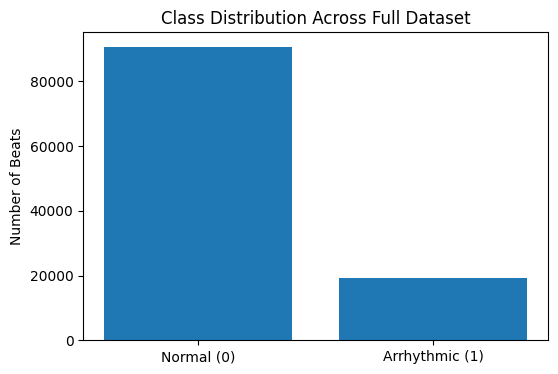


Full dataset class counts:
binary_label
0    90608
1    19332
Name: count, dtype: int64


In [35]:
#Plot class distribution across full dataset
full_counts = meta["binary_label"].value_counts().sort_index()

normal_count = full_counts.get(0, 0)
arr_count = full_counts.get(1, 0)

plt.figure(figsize=(6, 4))
plt.bar(["Normal (0)", "Arrhythmic (1)"], [normal_count, arr_count])
plt.title("Class Distribution Across Full Dataset")
plt.ylabel("Number of Beats")
plt.show()

print("\nFull dataset class counts:")
print(full_counts)



The bar graphs show there was a similar ratio of normal and arrhythmic beats per set illustrating that the beats are evenly distributed.

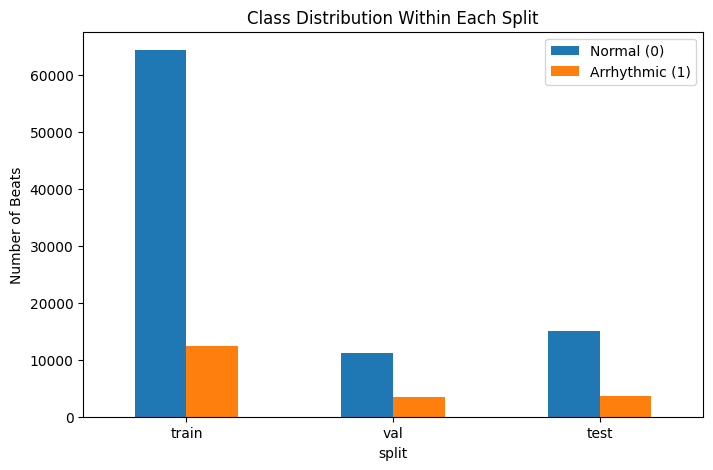


Class counts by split:
       Normal (0)  Arrhythmic (1)
split                            
train       64372           12331
val         11255            3433
test        14981            3568


In [36]:
#Plot class distribution within each split
split_class_counts = (
    meta.groupby(["split", "binary_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(["train", "val", "test"])
)

if 0 not in split_class_counts.columns:
    split_class_counts[0] = 0
if 1 not in split_class_counts.columns:
    split_class_counts[1] = 0

split_class_counts = split_class_counts[[0, 1]]
split_class_counts.columns = ["Normal (0)", "Arrhythmic (1)"]

split_class_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Class Distribution Within Each Split")
plt.ylabel("Number of Beats")
plt.xticks(rotation=0)
plt.show()

print("\nClass counts by split:")
print(split_class_counts)

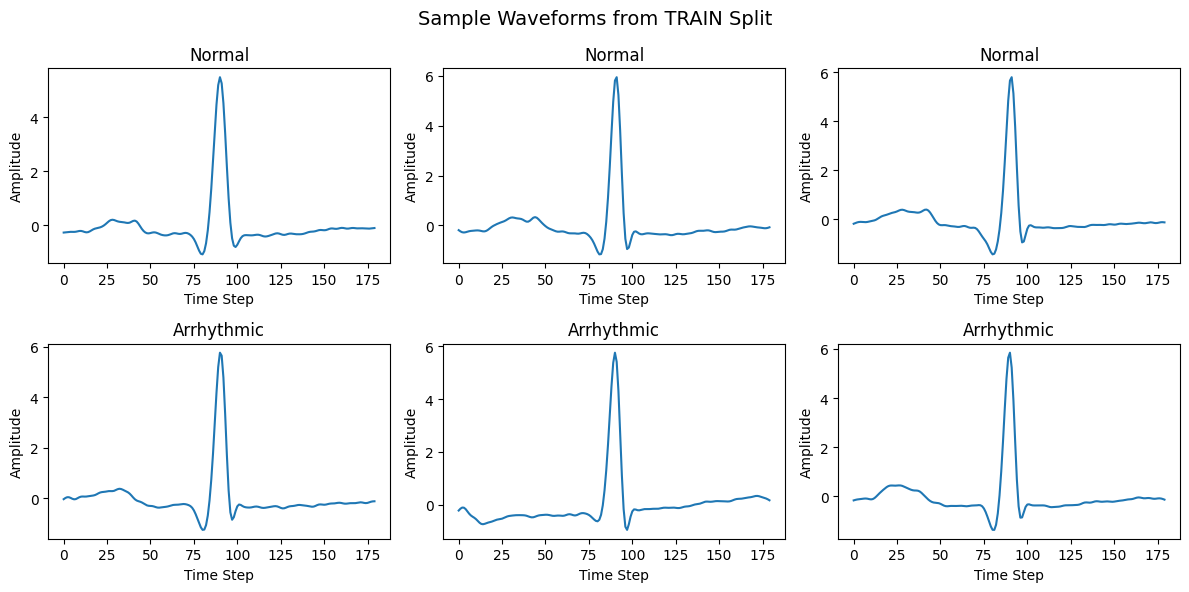

In [37]:
#plot sample waveforms
def plot_sample_beats(X_data, y_data, split_name, n_each=3):
    normal_idx = np.where(y_data == 0)[0]
    arr_idx = np.where(y_data == 1)[0]

    n_normal = min(n_each, len(normal_idx))
    n_arr = min(n_each, len(arr_idx))
    n_cols = max(n_normal, n_arr)

    fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 6), squeeze=False)
    fig.suptitle(f"Sample Waveforms from {split_name.upper()} Split", fontsize=14)

    for i in range(n_cols):
        if i < n_normal:
            axes[0, i].plot(X_data[normal_idx[i]])
            axes[0, i].set_title("Normal")
        axes[0, i].set_xlabel("Time Step")
        axes[0, i].set_ylabel("Amplitude")

        if i < n_arr:
            axes[1, i].plot(X_data[arr_idx[i]])
            axes[1, i].set_title("Arrhythmic")
        axes[1, i].set_xlabel("Time Step")
        axes[1, i].set_ylabel("Amplitude")

    plt.tight_layout()
    plt.show()

plot_sample_beats(X_train, y_train, "train", n_each=3)



In [38]:
#generate summary statistics table
summary_table = (
    meta.groupby(["patient_id", "split", "binary_label"])
    .size()
    .reset_index(name="beat_count")
    .sort_values(["split", "patient_id", "binary_label"])
)

print("\nSummary statistics table:")
print(summary_table.head(20))

summary_table.to_csv(f"{base_path}/summary_statistics_table.csv", index=False)

summary_pivot = (
    meta.groupby(["patient_id", "split", "binary_label"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

rename_dict = {}
if 0 in summary_pivot.columns:
    rename_dict[0] = "normal_beats"
if 1 in summary_pivot.columns:
    rename_dict[1] = "arrhythmic_beats"

summary_pivot = summary_pivot.rename(columns=rename_dict)

if "normal_beats" not in summary_pivot.columns:
    summary_pivot["normal_beats"] = 0
if "arrhythmic_beats" not in summary_pivot.columns:
    summary_pivot["arrhythmic_beats"] = 0

summary_pivot["total_beats"] = (
    summary_pivot["normal_beats"] + summary_pivot["arrhythmic_beats"]
)

print("\nPivot summary table:")
print(summary_pivot.head())

summary_pivot.to_csv(f"{base_path}/summary_statistics_pivot.csv", index=False)





Summary statistics table:
    patient_id  split  binary_label  beat_count
4          102   test             0          99
5          102   test             1        2088
6          103   test             0        2082
7          103   test             1           2
19         111   test             0        2123
20         111   test             1           1
45         201   test             0        1635
46         201   test             1         328
47         202   test             0        2061
48         202   test             1          75
49         203   test             0        2529
50         203   test             1         451
59         210   test             0        2421
60         210   test             1         227
74         221   test             0        2031
75         221   test             1         396
0          100  train             0        2237
1          100  train             1          34
2          101  train             0        1859
3          10

In [39]:
#write short summary document
total_beats = len(meta)
total_patients = meta["patient_id"].nunique()
normal_beats = int((meta["binary_label"] == 0).sum())
arr_beats = int((meta["binary_label"] == 1).sum())

train_beats = len(X_train)
val_beats = len(X_val)
test_beats = len(X_test)

train_pat_count = meta.loc[meta["split"] == "train", "patient_id"].nunique()
val_pat_count = meta.loc[meta["split"] == "val", "patient_id"].nunique()
test_pat_count = meta.loc[meta["split"] == "test", "patient_id"].nunique()

summary_text = f"""
Final Dataset Summary

This dataset contains cleaned heartbeat windows extracted from the MIT-BIH Arrhythmia Database.
After preprocessing, the final dataset includes {total_beats} beats from {total_patients} unique patients.

Class composition:
- Normal beats (label 0): {normal_beats}
- Arrhythmic beats (label 1): {arr_beats}

Patient-level splitting was used instead of beat-level splitting to prevent data leakage.
This ensures that all beats from the same patient appear in only one of the train, validation, or test sets.

Final split:
- Train: {train_beats} beats from {train_pat_count} patients
- Validation: {val_beats} beats from {val_pat_count} patients
- Test: {test_beats} beats from {test_pat_count} patients

Saved files:
- X_train.npy, y_train.npy
- X_val.npy, y_val.npy
- X_test.npy, y_test.npy
- metadata_with_splits.csv
- summary_statistics_table.csv
- summary_statistics_pivot.csv

Baseline visualizations were generated for:
1. Overall class distribution
2. Class balance across splits
3. Example heartbeat waveforms

This dataset is now ready for model training and evaluation.
"""

with open(f"{base_path}/final_dataset_summary.txt", "w") as f:
    f.write(summary_text)

print("\nSaved final_dataset_summary.txt")
print("\n----- Final Dataset Summary -----")
print(summary_text)


Saved final_dataset_summary.txt

----- Final Dataset Summary -----

Final Dataset Summary

This dataset contains cleaned heartbeat windows extracted from the MIT-BIH Arrhythmia Database.
After preprocessing, the final dataset includes 109940 beats from 48 unique patients.

Class composition:
- Normal beats (label 0): 90608
- Arrhythmic beats (label 1): 19332

Patient-level splitting was used instead of beat-level splitting to prevent data leakage.
This ensures that all beats from the same patient appear in only one of the train, validation, or test sets.

Final split:
- Train: 76703 beats from 33 patients
- Validation: 14688 beats from 7 patients
- Test: 18549 beats from 8 patients

Saved files:
- X_train.npy, y_train.npy
- X_val.npy, y_val.npy
- X_test.npy, y_test.npy
- metadata_with_splits.csv
- summary_statistics_table.csv
- summary_statistics_pivot.csv

Baseline visualizations were generated for:
1. Overall class distribution
2. Class balance across splits
3. Example heartbeat wav

Signal Preprocessing & Cleaning:

5) Feature Preparation & Data Readiness:
Here, we are preparing the data to be used for training our ML models.
We are:
- verifying the lables are correctly encoded,
- checking for missing values,
- showing the class distribution in the train, validation, and test sets,
- and shuffling the heartbeat data to prevent ordering bias


In [40]:
!pip install numpy pandas scikit-learn

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from collections import Counter

In [41]:
#load data
base_path = "/content/drive/MyDrive/xAI project"

X_train = np.load(f"{base_path}/X_train.npy")
y_train = np.load(f"{base_path}/y_train.npy")

X_val = np.load(f"{base_path}/X_val.npy")
y_val = np.load(f"{base_path}/y_val.npy")

X_test = np.load(f"{base_path}/X_test.npy")
y_test = np.load(f"{base_path}/y_test.npy")

In [42]:
#dataset shapes
print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (76703, 180) (76703,)
Validation shape: (14688, 180) (14688,)
Test shape: (18549, 180) (18549,)


In [43]:
#Verify label encoding (0 vs 1 )
print("Train labels:", np.unique(y_train))
print("Validation labels:", np.unique(y_val))
print("Test labels:", np.unique(y_test))

Train labels: [0 1]
Validation labels: [0 1]
Test labels: [0 1]


In [44]:
#check for missing values
def check_missing(X, name):
    print(f"{name} - Missing values:", np.isnan(X).sum())
    print(f"{name} - Infinite values:", np.isinf(X).sum())

check_missing(X_train, "Train")
check_missing(X_val, "Validation")
check_missing(X_test, "Test")

Train - Missing values: 0
Train - Infinite values: 0
Validation - Missing values: 0
Validation - Infinite values: 0
Test - Missing values: 0
Test - Infinite values: 0


In [45]:
from collections import Counter

#class distriburtion per split
def class_distribution(y, name):
    counts = Counter(y)
    total = len(y)
    print(f"{name} distribution:")
    for cls, count in counts.items():
        print(f"  Class {cls}: {count} ({count/total:.2%})")

class_distribution(y_train, "Train")
class_distribution(y_val, "Validation")
class_distribution(y_test, "Test")

Train distribution:
  Class 0: 64372 (83.92%)
  Class 1: 12331 (16.08%)
Validation distribution:
  Class 0: 11255 (76.63%)
  Class 1: 3433 (23.37%)
Test distribution:
  Class 1: 3568 (19.24%)
  Class 0: 14981 (80.76%)


In [46]:
from sklearn.preprocessing import StandardScaler

#normalize features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

#ensure fixed length feature vectors
print("Feature length:", X_train.shape[1])

#confirm ML format (samples x features)
print("X_train format:", X_train.shape)

Feature length: 180
X_train format: (76703, 180)


In [47]:
from sklearn.utils import shuffle
import numpy as np

# save copies before shuffle so we can verify it changed
X_train_before = X_train.copy()
y_train_before = y_train.copy()

# shuffle training data
X_train, y_train = shuffle(X_train, y_train, random_state=42)

# verify shuffle worked
print("Shuffle Check:")
print("Same shape:", X_train.shape == X_train_before.shape)
print("Order changed:", not np.array_equal(X_train, X_train_before))
print("First 5 labels after shuffle:", y_train[:5])

Shuffle Check:
Same shape: True
Order changed: True
First 5 labels after shuffle: [1 0 0 0 0]


In [48]:
base_path = "/content/drive/MyDrive/xAI project"

np.save(f"{base_path}/X_train_processed.npy", X_train)
np.save(f"{base_path}/y_train_processed.npy", y_train)

np.save(f"{base_path}/X_val_processed.npy", X_val)
np.save(f"{base_path}/y_val_processed.npy", y_val)

np.save(f"{base_path}/X_test_processed.npy", X_test)
np.save(f"{base_path}/y_test_processed.npy", y_test)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.


In [49]:
print("Sample Inspection:")
print("First processed sample (first 10 features):", X_train[0][:10])
print("First sample label:", y_train[0])

print("\n Summary Statistics:")
print("Training mean:", np.mean(X_train))
print("Training std:", np.std(X_train))
print("Training min:", np.min(X_train))
print("Training max:", np.max(X_train))

print("\n Missing/Corruption Check:")
print("NaNs in X_train:", np.isnan(X_train).sum())
print("Infs in X_train:", np.isinf(X_train).sum())

Sample Inspection:
First processed sample (first 10 features): [-0.83897651 -0.82591036 -0.79317776 -0.74480822 -0.69187689 -0.64722619
 -0.61946027 -0.60875561 -0.61056467 -0.6236439 ]
First sample label: 1

 Summary Statistics:
Training mean: -2.299626959738234e-16
Training std: 0.9999999999999997
Training min: -7.609283630897438
Training max: 14.917665563540009

 Missing/Corruption Check:
NaNs in X_train: 0
Infs in X_train: 0


Train Machine Learning Models:
1) We are using a Logistic Regression model because its interpretable by design, a Random Forest because it handles nonlinearity and imbalanced classes and a Linear SVM margin-based linear classifier included for comparison

In [50]:
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import SVC
from sklearn.metrics         import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)

In [51]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# Define base_path again for robustness against kernel restarts
base_path = "/content/drive/MyDrive/xAI project"

X_train = np.load(f"{base_path}/X_train_processed.npy")
y_train = np.load(f"{base_path}/y_train_processed.npy")

# Logistic Regression
# C = inverse regularization strength (smaller C = stronger regularization)
# max_iter increased because ECG feature space can be slow to converge

lr_model = LogisticRegression(
    C=0.1,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)
print("Logistic Regression trained ")

Logistic Regression trained 


In [52]:
# Random Forest
# n_estimators = number of trees; more = better but slower
# max_depth = limits how deep each tree grows (prevents overfitting)
# class_weight = 'balanced' is important because our dataset has more normal beats than arrhythmic

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Random Forest trained")

Random Forest trained


In [53]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
import numpy as np

base_path = "/content/drive/MyDrive/xAI project"

X_train = np.load(f"{base_path}/X_train_processed.npy")
y_train = np.load(f"{base_path}/y_train_processed.npy")

# LinearSVC doesn't have predict_proba built in,
# so we wrap it with CalibratedClassifierCV to get probabilities for ROC curves
svm_base = LinearSVC(
    C=0.1,
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)

svm_model = CalibratedClassifierCV(svm_base, cv=3)
svm_model.fit(X_train, y_train)
print("LinearSVM trained")

LinearSVM trained


In [99]:
#Evaluation helper
def evaluate_model(model, X, y, model_name):

    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]  # probability of class 1 (arrhythmic)

    acc    = accuracy_score(y, y_pred)
    f1     = f1_score(y, y_pred)
    roc    = roc_auc_score(y, y_proba)

    print(f"\n{'─'*50}")
    print(f"  {model_name}")
    print(f"{'─'*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc:.4f}")
    print()
    print(classification_report(y, y_pred, target_names=["Normal", "Arrhythmic"]))
    print(confusion_matrix(y, y_pred))

    return y_pred, y_proba, {"model": model_name, "accuracy": acc, "f1": f1, "roc_auc": roc}


# Run evaluation on the VALIDATION set
lr_pred,  lr_proba,  lr_metrics  = evaluate_model(lr_model,  X_val, y_val, "Logistic Regression")
rf_pred,  rf_proba,  rf_metrics  = evaluate_model(rf_model,  X_val, y_val, "Random Forest")
svm_pred, svm_proba, svm_metrics = evaluate_model(svm_model, X_val, y_val, "Linear SVM)")#Evaluation helper
def evaluate_model(model, X, y, model_name):

    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]  # probability of class 1 arrhythmic

    acc    = accuracy_score(y, y_pred)
    f1     = f1_score(y, y_pred)
    roc    = roc_auc_score(y, y_proba)

    print(f"\n{'─'*50}")
    print(f"  {model_name}")
    print(f"{'─'*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc:.4f}")
    print()
    print(classification_report(y, y_pred, target_names=["Normal", "Arrhythmic"]))
    print(confusion_matrix(y, y_pred))

    return y_pred, y_proba, {"model": model_name, "accuracy": acc, "f1": f1, "roc_auc": roc}


# Run evaluation on the VALIDATION set
lr_pred,  lr_proba,  lr_metrics  = evaluate_model(lr_model,  X_val, y_val, "Logistic Regression")
rf_pred,  rf_proba,  rf_metrics  = evaluate_model(rf_model,  X_val, y_val, "Random Forest")
svm_pred, svm_proba, svm_metrics = evaluate_model(svm_model, X_val, y_val, "Linear SVM")


──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
  Accuracy  : 0.8801
  F1 Score  : 0.6839
  ROC-AUC   : 0.8951

              precision    recall  f1-score   support

      Normal       0.88      0.98      0.93     11255
  Arrhythmic       0.89      0.55      0.68      3433

    accuracy                           0.88     14688
   macro avg       0.88      0.77      0.80     14688
weighted avg       0.88      0.88      0.87     14688

[[11022   233]
 [ 1528  1905]]

──────────────────────────────────────────────────
  Random Forest
──────────────────────────────────────────────────
  Accuracy  : 0.8798
  F1 Score  : 0.7795
  ROC-AUC   : 0.9490

              precision    recall  f1-score   support

      Normal       0.97      0.87      0.92     11255
  Arrhythmic       0.68      0.91      0.78      3433

    accuracy                           0.88     14688
   macro avg       0.83      0.89      0.85     1468

Support is the number of normal and arrhythmic beats used for each model.
Accuracy is the overall number of correct predictions.
ROC-AUC is the model's ability to distinguish between classes.
F1 score illustrates the harmonic mean of precision and recall.

The macro avg treats both classes as equally important while the weighted average takes into consideration if there are more normal or arrhythmic heartbeats.

As seen in the above and below metrics, the models seem to be quite comporable when analyzing their accuracy, f1 score and ROC-AUC. But upon further consideration, we see that the Random Forest has an overall higher f1-Score and ROC-AUC score. This means that the Random Forest model was able to accurately predict an arrhythmic hearbteat was actually arrythmic and that its was able to predict a large amount of the total normal heartbeats. The Random Forest's high AUC-ROC score means it was efficent at predicting betweent the normal and arrhythmic heartbeat signals.

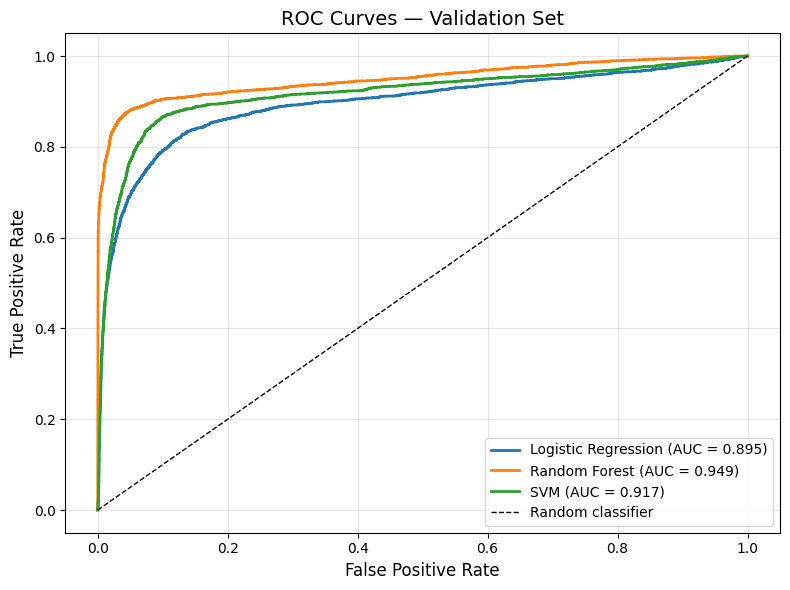

Saved roc_curves.png


In [55]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))

for (name, proba) in [("Logistic Regression", lr_proba),
                       ("Random Forest",       rf_proba),
                       ("SVM",                 svm_proba)]:
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc = roc_auc_score(y_val, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate",  fontsize=12)
ax.set_title("ROC Curves — Validation Set", fontsize=14)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{base_path}/roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved roc_curves.png")

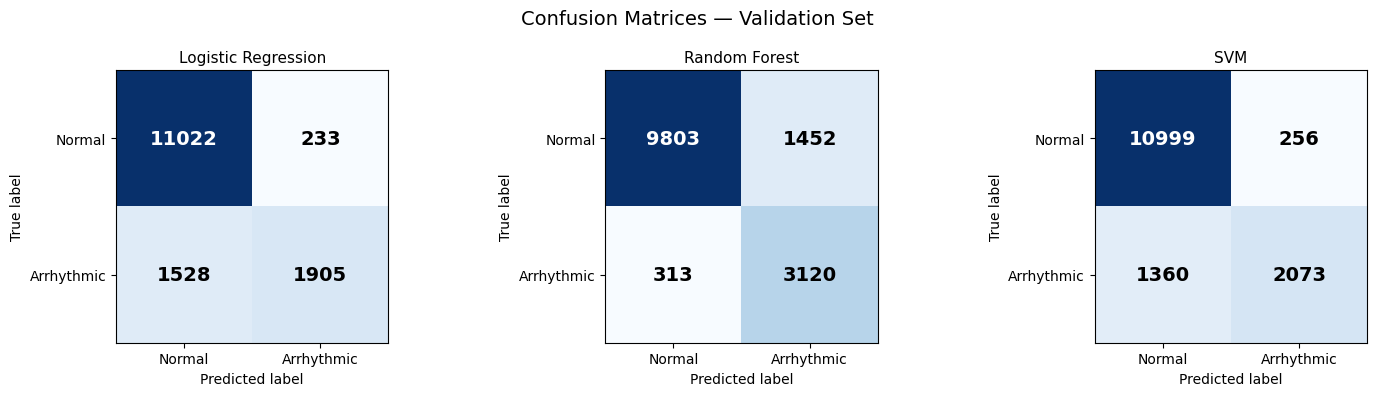

In [56]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Confusion Matrices — Validation Set", fontsize=14)

models_info = [
    ("Logistic Regression", lr_pred),
    ("Random Forest",       rf_pred),
    ("SVM",                 svm_pred),
]

for ax, (name, pred) in zip(axes, models_info):
    cm = confusion_matrix(y_val, pred)
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Normal", "Arrhythmic"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Normal", "Arrhythmic"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black',
                    fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{base_path}/confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

The Random Forest model has the lowest amount of false negatives which is good in comparison the the other higher false negatives. In a helathcare context, to falsely diagnose someone as healthy when they are sick could be fatal. This combined with the Random Forest model's high f1-score and ROC-AUC made it the optimal choice.

In [57]:
import os
import joblib
import numpy as np

models_dir = f"{base_path}/models"
os.makedirs(models_dir, exist_ok=True)

joblib.dump(lr_model,  f"{models_dir}/logistic_regression.pkl")
joblib.dump(rf_model,  f"{models_dir}/random_forest.pkl")
joblib.dump(svm_model, f"{models_dir}/svm.pkl")
print("Models saved")

preds_dir = f"{base_path}/predictions"
os.makedirs(preds_dir, exist_ok=True)

for name, pred, proba in [
    ("lr",  lr_pred,  lr_proba),
    ("rf",  rf_pred,  rf_proba),
    ("svm", svm_pred, svm_proba),
]:
    np.save(f"{preds_dir}/val_pred_{name}.npy",  pred)
    np.save(f"{preds_dir}/val_proba_{name}.npy", proba)

print("Predictions saved")
print("\nOutputs ready for Part 5 (visualization & xAI):")
print(f"  {models_dir}/")
print(f"  {preds_dir}/")
print(f"  {base_path}/model_comparison.csv")
print(f"  {base_path}/roc_curves.png")

Models saved
Predictions saved

Outputs ready for Part 5 (visualization & xAI):
  /content/drive/MyDrive/xAI project/models/
  /content/drive/MyDrive/xAI project/predictions/
  /content/drive/MyDrive/xAI project/model_comparison.csv
  /content/drive/MyDrive/xAI project/roc_curves.png


After training our model, we:

-Generated classification report for each model

-Created a summary table of model performance metrics

-Plotted comparison of key metrics (e.g., F1-score, accuracy),

-and Analyzed model behavior (false positives vs false negatives)

In [58]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/xAI project"
pred_path = "/content/drive/MyDrive/xAI project/predictions"
import numpy as np

# Load validation labels (still in main folder)
y_val = np.load(f"{base_path}/y_val_processed.npy")

# Load predictions from predictions folder
y_pred_lr = np.load(f"{pred_path}/val_pred_lr.npy")
y_proba_lr = np.load(f"{pred_path}/val_proba_lr.npy")

y_pred_rf = np.load(f"{pred_path}/val_pred_rf.npy")
y_proba_rf = np.load(f"{pred_path}/val_proba_rf.npy")

y_pred_svm = np.load(f"{pred_path}/val_pred_svm.npy")
y_proba_svm = np.load(f"{pred_path}/val_proba_svm.npy")

print("Loaded everything successfully!")


print("y_val shape:", y_val.shape)
print("Logistic Regression predictions shape:", y_pred_lr.shape)
print("Random Forest predictions shape:", y_pred_rf.shape)
print("SVM predictions shape:", y_pred_svm.shape)

Loaded everything successfully!
y_val shape: (14688,)
Logistic Regression predictions shape: (14688,)
Random Forest predictions shape: (14688,)
SVM predictions shape: (14688,)


In [60]:
#compute evaluation metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n{model_name}")
    print("-" * 40)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    return acc, prec, rec, f1

# Run for each model
lr_metrics = compute_metrics(y_val, y_pred_lr, "Logistic Regression")
rf_metrics = compute_metrics(y_val, y_pred_rf, "Random Forest")
svm_metrics = compute_metrics(y_val, y_pred_svm, "Linear SVM")


Logistic Regression
----------------------------------------
Accuracy : 0.8801
Precision: 0.8910
Recall   : 0.5549
F1-score : 0.6839

Random Forest
----------------------------------------
Accuracy : 0.8798
Precision: 0.6824
Recall   : 0.9088
F1-score : 0.7795

Linear SVM
----------------------------------------
Accuracy : 0.8900
Precision: 0.8901
Recall   : 0.6038
F1-score : 0.7195


Again, analyzing the performance of these models, we see that the logistic regression and linear SVM had a high accuracy and precision, indicating that it was able to classify between normal and arrhythmic classes well.

The random forest had lower precision, but had a much higher recall and f1-score. This means it was able to handle class imbalance well since we had more normal heartbeats than arrhythmic.


In [61]:
import pandas as pd
from sklearn.metrics import roc_auc_score

auc_lr = roc_auc_score(y_val, y_proba_lr)
auc_rf = roc_auc_score(y_val, y_proba_rf)
auc_svm = roc_auc_score(y_val, y_proba_svm)

results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Linear SVM"],
    "Accuracy": [lr_metrics[0], rf_metrics[0], svm_metrics[0]],
    "Precision": [lr_metrics[1], rf_metrics[1], svm_metrics[1]],
    "Recall": [lr_metrics[2], rf_metrics[2], svm_metrics[2]],
    "F1 Score": [lr_metrics[3], rf_metrics[3], svm_metrics[3]],
    "ROC-AUC": [auc_lr, auc_rf, auc_svm]
})


print("\nModel Performance Summary:")

results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

print(results_df.round(4))

results_df.to_csv(f"{base_path}/model_performance_summary.csv")
print("Saved: model_performance_summary.csv")


Model Performance Summary:
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
1        Random Forest    0.8798     0.6824  0.9088    0.7795   0.9490
2           Linear SVM    0.8900     0.8901  0.6038    0.7195   0.9172
0  Logistic Regression    0.8801     0.8910  0.5549    0.6839   0.8951
Saved: model_performance_summary.csv



False Positive vs False Negative Analysis:
                     False Positives (FP)  False Negatives (FN)
Model                                                          
Logistic Regression                   233                  1528
Random Forest                        1452                   313
Linear SVM                            256                  1360


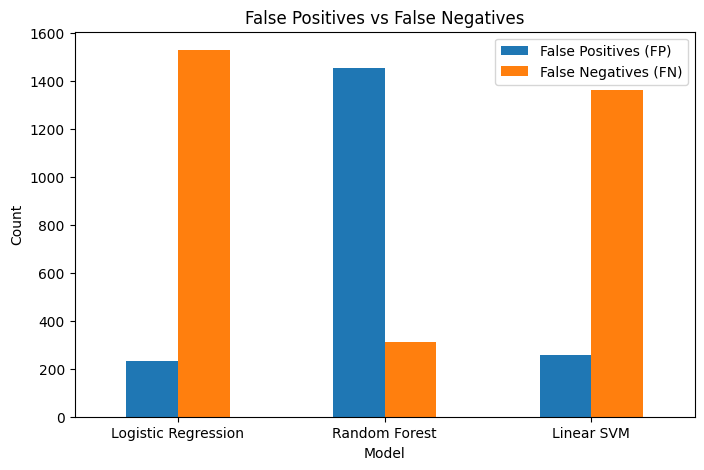

In [62]:
from sklearn.metrics import confusion_matrix
import pandas as pd

def get_fp_fn(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return fp, fn

# Get FP and FN for each model
fp_lr, fn_lr = get_fp_fn(y_val, y_pred_lr)
fp_rf, fn_rf = get_fp_fn(y_val, y_pred_rf)
fp_svm, fn_svm = get_fp_fn(y_val, y_pred_svm)

# Create table
fp_fn_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Linear SVM"],
    "False Positives (FP)": [fp_lr, fp_rf, fp_svm],
    "False Negatives (FN)": [fn_lr, fn_rf, fn_svm]
}).set_index("Model")

print("\nFalse Positive vs False Negative Analysis:")
print(fp_fn_df)

fp_fn_df.plot(kind="bar", figsize=(8,5))
plt.title("False Positives vs False Negatives")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

Overall, the Random Forest model achieved the best performance, with the highest ROC-AUC and recall, indicating a strong ability to correctly identify arrhythmic beats.

While Logistic Regression and Linear SVM produced fewer false positives, they exhibited significantly higher false negatives, meaning they frequently missed abnormal heartbeats.

In contrast, Random Forest reduced false negatives substantially, making it more suitable for this medical application despite generating more false positives.

This tradeoff is important, as missing an arrhythmia poses greater risk than a false alarm. Additionally, challenges such as class imbalance, overlapping signal patterns, and noise in ECG data contributed to classification difficulty and impacted model performance.

Overall, the results highlight the importance of prioritizing recall and interpretability when developing models for healthcare applications.


The reason as to why these metrics resulted in the way they did could be due to class imbalance. We had significantly more normal beats than arrhythmic.

This can bias models toward predicting the majority class, resulting in higher false negatives and reduced sensitivity to abnormal patterns.

Second, there is overlap between normal and arrhythmic signal patterns, as some abnormal beats closely resemble normal ones, making it difficult for models to clearly distinguish between the two classes.

Finally, ECG signals are inherently noisy and can vary across patients, further complicating the classification task. These challenges contribute to the observed trade-offs between false positives and false negatives across the models.

## Applying XAI Methods to test Stability

After training our chosen model, we then applied SHAP and LIME to explain our random forest model's predictions. Once we got our prediction, we added noise to our heartbeat samples and applied SHAP and LIME once more to analyze the results.

We were looking for little variation in the explanations before and after noise.


In [63]:
!pip install lime shap wfdb numpy matplotlib pandas scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=3b5822a849c0b3e83b83ac67be562b3d2a1c9a5b42b2b45dfb325374ba756396
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


Here we created a directory to put our LIME related data.

In [64]:
import lime
import lime.lime_tabular
import joblib
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score

base_path = '/content/drive/MyDrive/xAI project'
models_dir = f'{base_path}/models'

# Output directory for LIME results
output_dir = f'{base_path}/lime'
os.makedirs(output_dir, exist_ok=True)
print('LIME output directory created:', output_dir)

LIME output directory created: /content/drive/MyDrive/xAI project/lime


In [65]:
# Load trained Random Forest model and data
rf_model = joblib.load(f'{models_dir}/random_forest.pkl')

X_train = np.load(f'{base_path}/X_train_processed.npy')
y_train = np.load(f'{base_path}/y_train_processed.npy')

X_test = np.load(f'{base_path}/X_test_processed.npy')
y_test = np.load(f'{base_path}/y_test_processed.npy')

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
print('y_test shape :', y_test.shape)
print('Class counts  :', dict(zip(*np.unique(y_test, return_counts=True))))

X_train shape: (76703, 180)
X_test shape : (18549, 180)
y_test shape : (18549,)
Class counts  : {np.int64(0): np.int64(14981), np.int64(1): np.int64(3568)}


From our test set, we chose 100 heartbeat samples, 50 normal and 50 arrhythmic.

In [66]:
# Sample 50 normal + 50 arrhythmic beats from test set
np.random.seed(42)

normal_idx     = np.where(y_test == 0)[0]
arrhythmic_idx = np.where(y_test == 1)[0]

n_sample = min(50, len(normal_idx), len(arrhythmic_idx))
print(f'Sampling {n_sample} Normal and {n_sample} Arrhythmic beats')

sel_normal     = np.random.choice(normal_idx,     n_sample, replace=False)
sel_arrhythmic = np.random.choice(arrhythmic_idx, n_sample, replace=False)
selected_idx   = np.concatenate([sel_normal, sel_arrhythmic])

X_sample = X_test[selected_idx]   # (100, 180)
y_sample = y_test[selected_idx]   # (100,)

print('X_sample shape:', X_sample.shape)
print('y_sample distribution:', dict(zip(*np.unique(y_sample, return_counts=True))))

Sampling 50 Normal and 50 Arrhythmic beats
X_sample shape: (100, 180)
y_sample distribution: {np.int64(0): np.int64(50), np.int64(1): np.int64(50)}


## Applying XAI Methods to test Stability
  1) Create LIME explainer

A LIME explainer was initialized using our training data to establish the background distribution of each feature. Features were the segments of the heartbeat sample that meaningfully contributed to the prediction of normal or arrhythmic.

To generate an explanation, each heartbeat sample was perturbed and a local linear model was fit on the resulting perturbations. A feature importance score was then generated for each feature by analyzing how the perturbations  affected the model's prediction.


In [67]:
# Create LIME explainer using training data as the background distribution
feature_names = [f'timestep_{i}' for i in range(X_train.shape[1])]

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train,
    mode='classification',
    class_names=['Normal', 'Arrhythmic'],
    feature_names=feature_names,
    random_state=42
)

print('LIME explainer created.')
print(f'Training background size : {X_train.shape[0]} samples')
print(f'Number of features       : {X_train.shape[1]} time-steps')

LIME explainer created.
Training background size : 76703 samples
Number of features       : 180 time-steps


Next, we are generated a LIME explanation for each of the 100 heartbeat samples.

In [68]:
# Generate LIME explanations for all 100 sampled beats
# local_exp[1] returns [(feature_index, weight), ...] for class 1 (Arrhythmic)
# Each row of lime_matrix is a unique explanation — unlike np.tile which copies one vector

print('Generating LIME explanations for 100 samples...')

lime_matrix = np.zeros((len(X_sample), X_train.shape[1]))  # (100, 180)

for i, beat in enumerate(X_sample):
    exp = lime_explainer.explain_instance(
        data_row=beat,
        predict_fn=rf_model.predict_proba,
        num_features=X_train.shape[1],  # request all 180 time-step weights
        num_samples=1000,               # perturbation samples for local fit
        labels=(1,)                     # explain class 1: Arrhythmic
    )
    # Extract weights by feature index directly avoids string parsing
    for feat_idx, weight in exp.local_exp[1]:
        lime_matrix[i, feat_idx] = weight

    if (i + 1) % 10 == 0:
        print(f'  Processed {i+1}/100 beats')

print(f'\nLIME matrix shape: {lime_matrix.shape}')  # (100, 180)
print('Each row is a unique explanation — instance-specific.')
print('Verify: are rows different from each other?')
print('Row 0 == Row 1:', np.array_equal(lime_matrix[0], lime_matrix[1]))

Generating LIME explanations for 100 samples...
  Processed 10/100 beats
  Processed 20/100 beats
  Processed 30/100 beats
  Processed 40/100 beats
  Processed 50/100 beats
  Processed 60/100 beats
  Processed 70/100 beats
  Processed 80/100 beats
  Processed 90/100 beats
  Processed 100/100 beats

LIME matrix shape: (100, 180)
Each row is a unique explanation — instance-specific.
Verify: are rows different from each other?
Row 0 == Row 1: False


In [69]:
# Mean absolute LIME importance across all 100 samples
# This gives a summary view of which time-steps matter on average
mean_lime_importance = np.mean(np.abs(lime_matrix), axis=0)  # (180,)

top10_idx = np.argsort(mean_lime_importance)[::-1][:10]
print('Top-10 most important time-steps (by mean |LIME weight|):', sorted(top10_idx))

# Find the most important 10-step window
window_size = 10
window_sums = [mean_lime_importance[i:i+window_size].sum()
               for i in range(len(mean_lime_importance) - window_size)]
best_window_start = int(np.argmax(window_sums))
best_window_end   = best_window_start + window_size
print(f'Most important {window_size}-step window: indices {best_window_start}-{best_window_end}')

Top-10 most important time-steps (by mean |LIME weight|): [np.int64(39), np.int64(42), np.int64(78), np.int64(79), np.int64(89), np.int64(90), np.int64(91), np.int64(92), np.int64(97), np.int64(98)]
Most important 10-step window: indices 89-99


LIME got the mean absolute importance score for the heartbeat samples and determined the above indices were most important for heartbeat classification.

In [70]:

np.save(f'{output_dir}/lime_matrix.npy',      lime_matrix)        # (100, 180) instance-specific
np.save(f'{output_dir}/lime_mean_importance.npy', mean_lime_importance)  # (180,) summary
np.save(f'{output_dir}/X_sample_lime.npy',    X_sample)           # (100, 180)
np.save(f'{output_dir}/y_sample_lime.npy',    y_sample)           # (100,)
np.save(f'{output_dir}/selected_indices.npy', selected_idx)       # (100,)

print('Saved files to', output_dir)
print('  lime_matrix.npy          — (100, 180) instance-specific LIME weights')
print('  lime_mean_importance.npy — (180,) mean |LIME| across 100 samples')
print('  X_sample_lime.npy        — (100, 180) the 100 test beats used')
print('  y_sample_lime.npy        — (100,) their labels')
print('  selected_indices.npy     — (100,) their original indices in X_test')

Saved files to /content/drive/MyDrive/xAI project/lime
  lime_matrix.npy          — (100, 180) instance-specific LIME weights
  lime_mean_importance.npy — (180,) mean |LIME| across 100 samples
  X_sample_lime.npy        — (100, 180) the 100 test beats used
  y_sample_lime.npy        — (100,) their labels
  selected_indices.npy     — (100,) their original indices in X_test


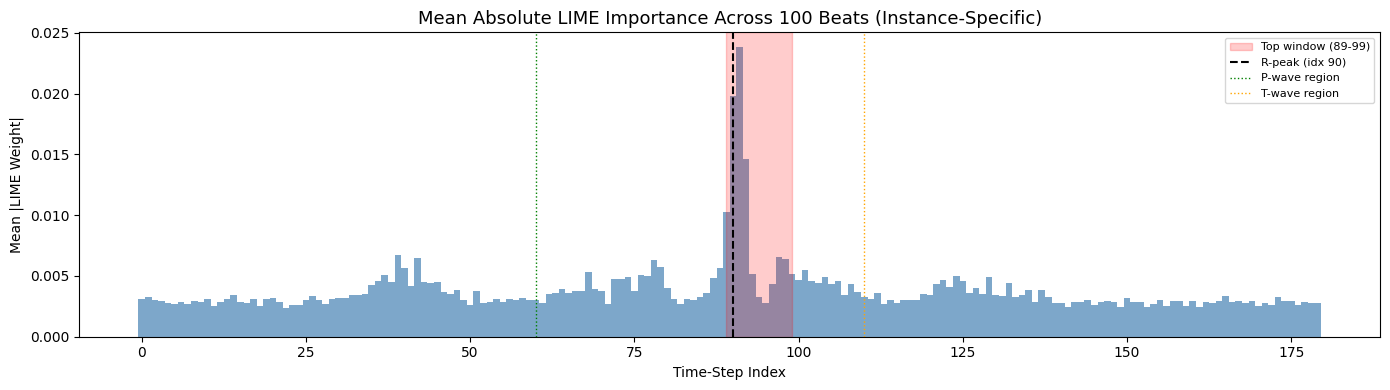

Saved: lime_mean_importance_plot.png


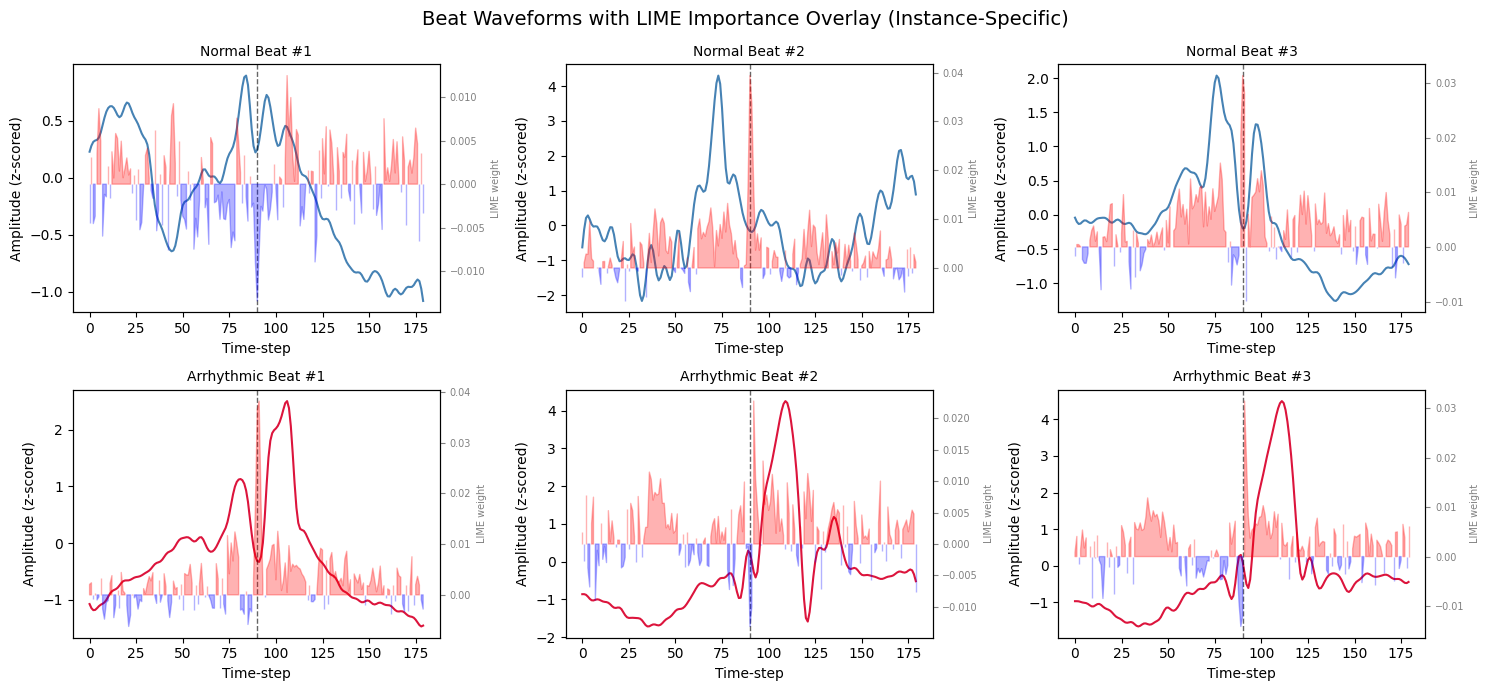

Saved: beat_lime_overlay.png
Note: each beat above has a DIFFERENT LIME profile — confirming instance-specificity.


In [71]:
# Visualize mean LIME importance across all 100 samples
r_peak = 90
time_steps = np.arange(len(mean_lime_importance))

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(time_steps, mean_lime_importance, color='steelblue', alpha=0.7, width=1)
ax.axvspan(best_window_start, best_window_end, alpha=0.2, color='red',
           label=f'Top window ({best_window_start}-{best_window_end})')
ax.axvline(r_peak,      color='black',  linestyle='--', linewidth=1.5, label='R-peak (idx 90)')
ax.axvline(r_peak - 30, color='green',  linestyle=':',  linewidth=1,   label='P-wave region')
ax.axvline(r_peak + 20, color='orange', linestyle=':',  linewidth=1,   label='T-wave region')
ax.set_title('Mean Absolute LIME Importance Across 100 Beats (Instance-Specific)', fontsize=13)
ax.set_xlabel('Time-Step Index')
ax.set_ylabel('Mean |LIME Weight|')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{output_dir}/lime_mean_importance_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lime_mean_importance_plot.png')

# Overlay LIME importance on 6 individual beats (3 normal, 3 arrhythmic)
# Each beat has a DIFFERENT importance profile, this is the key advantage over the previous approach
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('Beat Waveforms with LIME Importance Overlay (Instance-Specific)', fontsize=14)

for col in range(3):
    for row, (label_val, label_name, color) in enumerate(
            [(0, 'Normal', 'steelblue'), (1, 'Arrhythmic', 'crimson')]):

        group_idx = np.where(y_sample == label_val)[0]
        beat      = X_sample[group_idx[col]]
        lime_imp  = lime_matrix[group_idx[col]]  # unique per beat

        ax = axes[row, col]
        ax2 = ax.twinx()

        ax.plot(beat, color=color, linewidth=1.5, label='ECG signal')
        ax2.fill_between(time_steps, lime_imp,
                         where=lime_imp > 0, alpha=0.3, color='red',   label='LIME+ (pushes Arrhythmic)')
        ax2.fill_between(time_steps, lime_imp,
                         where=lime_imp < 0, alpha=0.3, color='blue',  label='LIME- (pushes Normal)')
        ax2.set_ylabel('LIME weight', fontsize=7, color='gray')
        ax2.tick_params(axis='y', colors='gray', labelsize=7)
        ax.axvline(r_peak, color='black', linestyle='--', linewidth=1, alpha=0.6)
        ax.set_title(f'{label_name} Beat #{col+1}', fontsize=10)
        ax.set_xlabel('Time-step')
        ax.set_ylabel('Amplitude (z-scored)')

plt.tight_layout()
plt.savefig(f'{output_dir}/beat_lime_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: beat_lime_overlay.png')
print('Note: each beat above has a DIFFERENT LIME profile — confirming instance-specificity.')

The LIME overlays show that each beat receives a unique importance profile, with positive weights (red) indicating time-steps that push the prediction toward Arrhythmic and negative weights (blue) indicating time-steps that push toward Normal. These explanations reflect the model's local behavior around each individual heartbeat, making the comparison with SHAP methodologically valid.

## Applying XAI Methods to test Stability
  2) Create SHAP values

After identifying the significant regions within the 100-sample subset, we conducted our stability experiment. Initial SHAP values were generated for the selected heartbeat samples to establish a baseline of feature importance. These samples were then subjected to perturbations, and SHAP explanations were reapplied. By comparing the consistency of the SHAP values before and after the introduction of noise, the model's explanatory stability was quantified.

In [72]:
import shap

# Load sample beats from LIME output directory (renamed from X_sample_saliency.npy)
lime_dir = f"{base_path}/lime"
heartbeat_samples = np.load(f"{lime_dir}/X_sample_lime.npy")

#we are making an explainer object for Random Forest model
explainer = shap.TreeExplainer(rf_model)
shap_explanations_org_samples = explainer(heartbeat_samples)



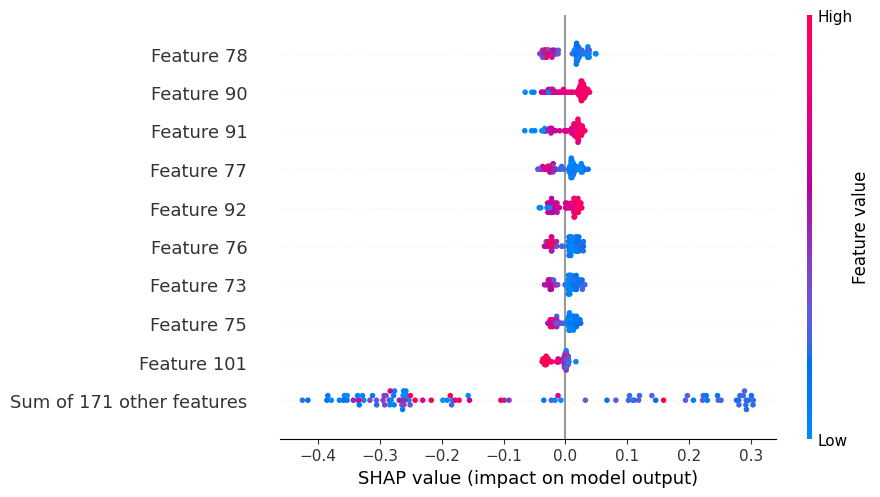

In [73]:
#visualize shap - the 0 is for why the model predicted a sample was normal. 1 is for why the model predicted a sample was aryythmic
shap.plots.beeswarm(shap_explanations_org_samples[:,:,0])






As seen in the above graph, the beeswarm plot is showing the distribution per feature of SHAP values positively and negatively contributing to class 0. Feature 90 and 91 are shown to have a high negative contribution to predicting a normal heartbeat. Feature 76, 73, and 75, for example, showed to contribute less for predicting a normal heartbeat.

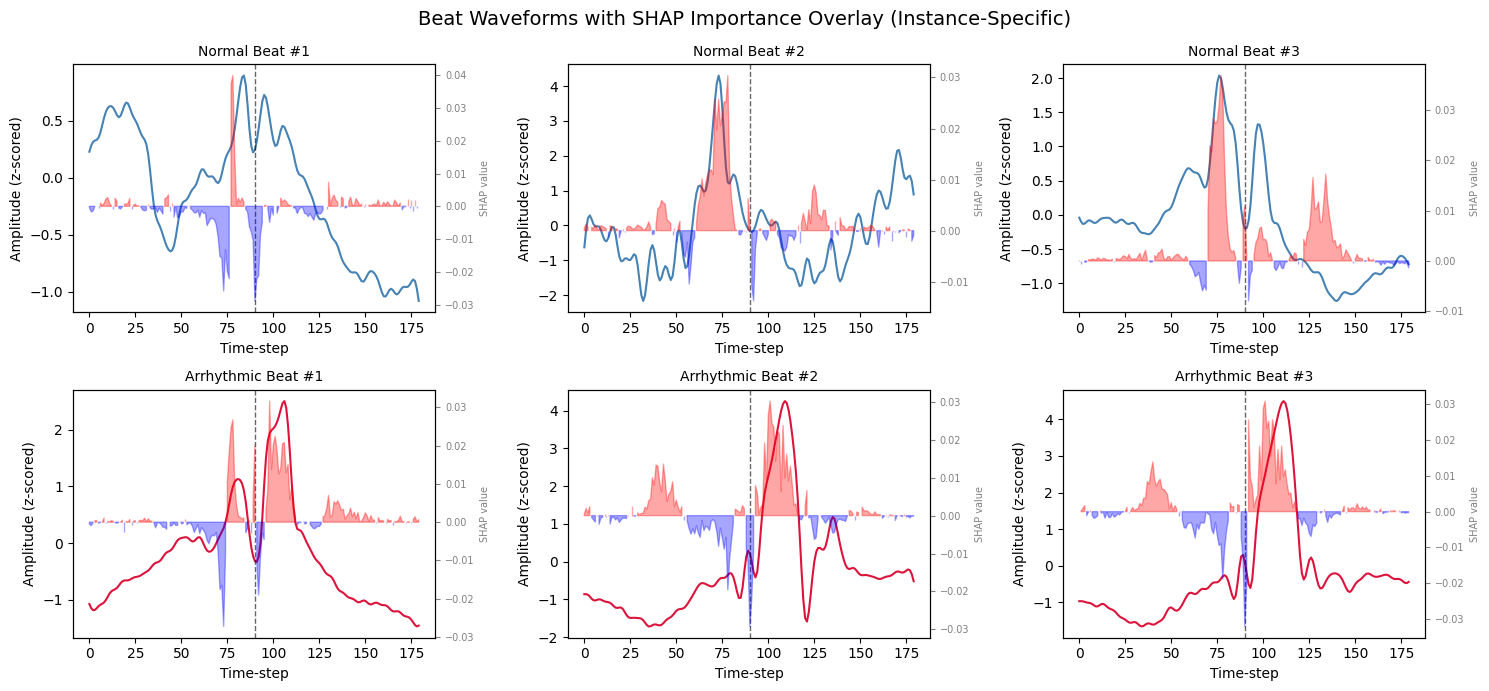

Saved: shap_beat_grid.png


In [74]:
# SHAP 3x2 Beat Grid — mirrors the LIME beat grid for direct comparison
# Each beat has a unique SHAP profile — instance-specific
import numpy as np
import matplotlib.pyplot as plt

base_path_ = '/content/drive/MyDrive/xAI project'

clean_shap = np.load(f'{base_path_}/shap_explanations_org.npy')
X_sample   = np.load(f'{base_path_}/lime/X_sample_lime.npy')
y_sample   = np.load(f'{base_path_}/lime/y_sample_lime.npy')


fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('Beat Waveforms with SHAP Importance Overlay (Instance-Specific)', fontsize=14)

time_steps = np.arange(180)
r_peak = 90


for col in range(3):
    for row, (label_val, label_name, color) in enumerate(
            [(0, 'Normal', 'steelblue'), (1, 'Arrhythmic', 'crimson')]):

        group_idx = np.where(y_sample == label_val)[0]
        beat_i    = X_sample[group_idx[col]]
        shap_imp  = clean_shap[group_idx[col]]

        ax  = axes[row, col]
        ax2 = ax.twinx()

        # Plot ECG waveform
        ax.plot(beat_i, color=color, linewidth=1.5, label='ECG signal')

        # Overlay signed SHAP values
        # Red = pushes toward Arrhythmic, Blue = pushes toward Normal
        ax2.fill_between(time_steps, shap_imp,
                         where=shap_imp > 0, alpha=0.35, color='red',
                         label='SHAP+ (toward Arrhythmic)')
        ax2.fill_between(time_steps, shap_imp,
                         where=shap_imp < 0, alpha=0.35, color='blue',
                         label='SHAP- (toward Normal)')
        ax2.set_ylabel('SHAP value', fontsize=7, color='gray')
        ax2.tick_params(axis='y', colors='gray', labelsize=7)

        ax.axvline(r_peak, color='black', linestyle='--', linewidth=1, alpha=0.6)
        ax.set_title(f'{label_name} Beat #{col+1}', fontsize=10)
        ax.set_xlabel('Time-step')
        ax.set_ylabel('Amplitude (z-scored)')

plt.tight_layout()
plt.savefig(f'{base_path}/shap_beat_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_beat_grid.png')

Now that we have generated SHAP explanations, we are now going to add some noise to our samples and reapply SHAP

We used the guassion noise method and generating noise by rolling the heartbeat signals, but ultimately continued our experiment with the gaussian noise added signals.

In [75]:
#add gaussian noise
stds = np.std(heartbeat_samples, axis=1)

#multiply std devs by a fraction to ensure that if a heartbeat has a particulary large spike, the noise is not so unnatural
noise = np.random.normal(loc=0, scale = stds[:, np.newaxis] *0.10, size = heartbeat_samples.shape)

noised_signals = heartbeat_samples + noise

print("-----------------Heartbeat Samples before noise-------------")
print(heartbeat_samples)
print("-------------------Heartbeat Samples after noise-------------")
print(noised_signals)

-----------------Heartbeat Samples before noise-------------
[[ 0.2289604   0.28238112  0.31553035 ... -0.90596208 -0.97296541
  -1.07994807]
 [-0.62698162 -0.11446545  0.21646772 ...  1.42620571  1.26547287
   0.88991722]
 [-0.0411741  -0.1019824  -0.13319823 ... -0.63488688 -0.67444487
  -0.72038791]
 ...
 [-1.12997724 -1.20579584 -1.25298452 ... -1.38174819 -1.33145642
  -1.20203576]
 [-0.10482518 -0.11398035 -0.13010788 ... -0.04572083 -0.16470302
  -0.35196264]
 [ 0.04824861  0.17976566  0.27912926 ...  2.63245829  2.50482016
   2.26980884]]
-------------------Heartbeat Samples after noise-------------
[[ 0.28875     0.26888222  0.29704177 ... -0.97643638 -0.96902388
  -1.06537593]
 [-0.72663714 -0.12613648  0.11065173 ...  1.51387378  1.24704372
   0.86782367]
 [-0.0624077  -0.09033972 -0.14338943 ... -0.69064456 -0.59284561
  -0.76983383]
 ...
 [-1.41268231 -1.01229851 -1.45498162 ... -1.33744999 -1.30905017
  -1.2674707 ]
 [-0.14076231 -0.20764113 -0.23670221 ... -0.11383576 -0

In [76]:
#shifting the data

#random arr of ints between 5-10
arr_rand_rolls = np.random.randint(5,10, size=100)

#empty np array to hold rolled sigs
new_rolled_heartbeat_sigs = np.zeros([100,180])

i=0
for signal in heartbeat_samples:
  shifted_signal = np.roll(signal, shift = arr_rand_rolls[i])
  new_rolled_heartbeat_sigs[i] = shifted_signal
  i+=1


#shifted_data = np.roll(heartbeat_samples, shift=5, axis=1)

print("Samples before rolling")
print(heartbeat_samples)
print("Heartbeat Samples after rolling")
print(new_rolled_heartbeat_sigs)

Samples before rolling
[[ 0.2289604   0.28238112  0.31553035 ... -0.90596208 -0.97296541
  -1.07994807]
 [-0.62698162 -0.11446545  0.21646772 ...  1.42620571  1.26547287
   0.88991722]
 [-0.0411741  -0.1019824  -0.13319823 ... -0.63488688 -0.67444487
  -0.72038791]
 ...
 [-1.12997724 -1.20579584 -1.25298452 ... -1.38174819 -1.33145642
  -1.20203576]
 [-0.10482518 -0.11398035 -0.13010788 ... -0.04572083 -0.16470302
  -0.35196264]
 [ 0.04824861  0.17976566  0.27912926 ...  2.63245829  2.50482016
   2.26980884]]
Heartbeat Samples after rolling
[[-0.95553516 -0.95754426 -0.95641828 ... -1.01298201 -0.987635
  -0.96448141]
 [ 1.37120738  1.32624202  1.40096587 ...  2.16665647  1.94142918
   1.60941711]
 [-0.6416211  -0.60748801 -0.5987879  ... -0.77428529 -0.7471284
  -0.69545593]
 ...
 [-1.14912303 -1.21094985 -1.29375301 ... -1.12950709 -1.12555391
  -1.12419631]
 [-0.28467466 -0.14560149 -0.04480724 ... -0.58953879 -0.53759327
  -0.42736144]
 [ 2.2583526   2.3205975   2.41721078 ...  2.1

Noisy samples SHAP explanations Class 0 and 1


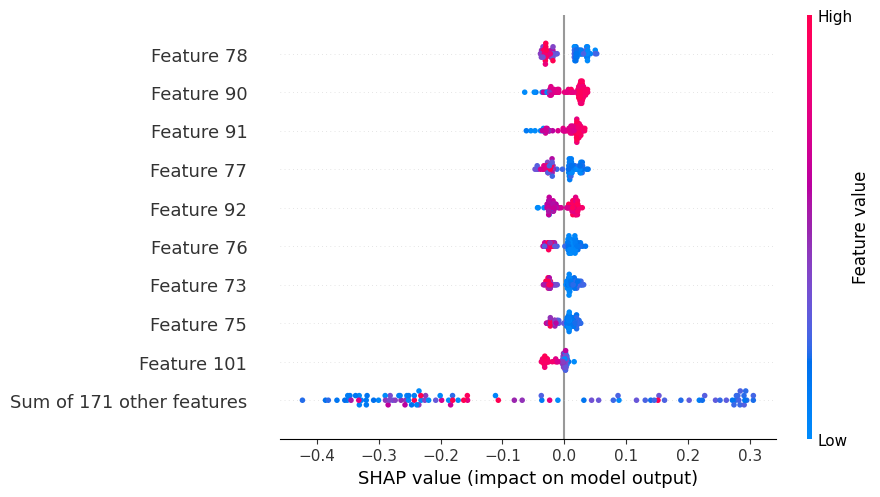

In [77]:
#now generating new shap values on shifted signals and noisy singals
shap_explanations_noisy_samples = explainer(noised_signals)
shap_explanations_shifted_samples = explainer(new_rolled_heartbeat_sigs)

#visualize noisy samples
print("Noisy samples SHAP explanations Class 0 and 1")
shap.plots.beeswarm(
shap_explanations_noisy_samples[:,:,0])


After applying noise and then reapplying SHAP, there is a very clear similarity to the above graph. This in itself visually shows that the above features are contributing similarily to predicting the normal class before and after noise is added.

In [78]:
#saving the noisy signals, shifted signals, and original shap values

#this is specifying that we are saving the SHAP values applied for the aryythmic class. If shap values for the Normal
#class are needed, can access by hap_explanations_org_samples.values[:, :, 0] for ex

base_path_ = "/content/drive/MyDrive/xAI project"
os.makedirs(base_path_, exist_ok=True)
np.save(f"{base_path_}/shap_explanations_org",    shap_explanations_org_samples.values[:, :, 1])
np.save(f"{base_path_}/shap_explanations_noisy_signals",    shap_explanations_noisy_samples.values[:, :, 1])
np.save(f"{base_path_}/shap_explanations_shifted_signals",    shap_explanations_shifted_samples.values[:, :, 1])

In [79]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np

base_path_ = "/content/drive/MyDrive/xAI project"

# make folder
os.makedirs(base_path_, exist_ok=True)


np.save(f"{base_path_}/shap_explanations_org",
        shap_explanations_org_samples.values[:, :, 1])

np.save(f"{base_path_}/shap_explanations_noisy_signals",
        shap_explanations_noisy_samples.values[:, :, 1])

np.save(f"{base_path_}/shap_explanations_shifted_signals",
        shap_explanations_shifted_samples.values[:, :, 1])

print("Files in folder AFTER saving:")
print(os.listdir(base_path_))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in folder AFTER saving:
['mit-bit-dataset', 'mit-bit-dataset\\beats.npy', 'mit-bit-dataset\\labels.npy', 'mit-bit-dataset\\metadata.csv', 'models', 'predictions', 'saliency', 'xai project: weekly to-do.gdoc', 'XAIproject.ipynb', 'lime', 'heartbeat_window_annotated.png', 'lime_beeswarm.png', 'model_comparison.csv', 'cleaned_beat_signals.npy', 'X_train.npy', 'X_val.npy', 'X_test.npy', 'X_train_processed.npy', 'X_val_processed.npy', 'X_test_processed.npy', 'y_train.npy', 'y_test.npy', 'metadata_with_splits.csv', 'y_val.npy', 'final_dataset_summary.txt', 'summary_statistics_pivot.csv', 'summary_statistics_table.csv', 'y_train_processed.npy', 'y_val_processed.npy', 'y_test_processed.npy', 'roc_curves.png', 'confusion_matrices.png', 'model_performance_summary.csv', 'shap_explanations_org.npy', 'shap_explanations_noisy_signals.npy', 'shap_explanations_shifted_

## Applying XAI Methods to test Stability

3) Test LIME stability with pertubations

We now generate LIME explanations on the noisy and shifted signals, mirroring the SHAP stability experiment. This allows a direct, methodologically equal comparison: both SHAP and LIME are instance-specific methods evaluated under the same perturbations using the same Spearman rank correlation metric.

In [80]:
# Generate LIME explanations on noisy signals
# noised_signals and new_rolled_heartbeat_sigs were created in the SHAP section above

print('Generating LIME explanations on noisy signals...')
lime_matrix_noisy = np.zeros((len(noised_signals), X_train.shape[1]))

for i, beat in enumerate(noised_signals):
    exp = lime_explainer.explain_instance(
        data_row=beat,
        predict_fn=rf_model.predict_proba,
        num_features=X_train.shape[1],
        num_samples=1000,
        labels=(1,)
    )
    for feat_idx, weight in exp.local_exp[1]:
        lime_matrix_noisy[i, feat_idx] = weight
    if (i + 1) % 10 == 0:
        print(f'  Processed {i+1}/100 noisy beats')

print('\nGenerating LIME explanations on shifted signals')
lime_matrix_shifted = np.zeros((len(new_rolled_heartbeat_sigs), X_train.shape[1]))

for i, beat in enumerate(new_rolled_heartbeat_sigs):
    exp = lime_explainer.explain_instance(
        data_row=beat,
        predict_fn=rf_model.predict_proba,
        num_features=X_train.shape[1],
        num_samples=1000,
        labels=(1,)
    )
    for feat_idx, weight in exp.local_exp[1]:
        lime_matrix_shifted[i, feat_idx] = weight
    if (i + 1) % 10 == 0:
        print(f'  Processed {i+1}/100 shifted beats')

print('\nDone. Saving LIME noisy/shifted explanations')
np.save(f'{output_dir}/lime_matrix_noisy.npy',   lime_matrix_noisy)
np.save(f'{output_dir}/lime_matrix_shifted.npy', lime_matrix_shifted)
print('Saved lime_matrix_noisy.npy and lime_matrix_shifted.npy')

Generating LIME explanations on noisy signals...
  Processed 10/100 noisy beats
  Processed 20/100 noisy beats
  Processed 30/100 noisy beats
  Processed 40/100 noisy beats
  Processed 50/100 noisy beats
  Processed 60/100 noisy beats
  Processed 70/100 noisy beats
  Processed 80/100 noisy beats
  Processed 90/100 noisy beats
  Processed 100/100 noisy beats

Generating LIME explanations on shifted signals
  Processed 10/100 shifted beats
  Processed 20/100 shifted beats
  Processed 30/100 shifted beats
  Processed 40/100 shifted beats
  Processed 50/100 shifted beats
  Processed 60/100 shifted beats
  Processed 70/100 shifted beats
  Processed 80/100 shifted beats
  Processed 90/100 shifted beats
  Processed 100/100 shifted beats

Done. Saving LIME noisy/shifted explanations
Saved lime_matrix_noisy.npy and lime_matrix_shifted.npy


## Applying XAI Methods to test Stability
 4) Stability Metrics: SHAP vs LIME (Spearman Rank Correlation)

 We are using the Spearman Rank Correlation to determine how related the original explanations and the noisy explanations are.



In [81]:
import numpy as np
from scipy.stats import spearmanr

base_path_ = '/content/drive/MyDrive/xAI project'

#Load SHAP explanations
clean_shap = np.load(f'{base_path_}/shap_explanations_org.npy')
noisy_shap = np.load(f'{base_path_}/shap_explanations_noisy_signals.npy')

#Load LIME explanations
# lime_matrix and lime_matrix_noisy are already in memory from cells above
# If restarting kernel, reload from disk:
# lime_matrix       = np.load(f'{base_path_}/lime/lime_matrix.npy')
# lime_matrix_noisy = np.load(f'{base_path_}/lime/lime_matrix_noisy.npy')

print('clean_shap shape:', clean_shap.shape)
print('lime_matrix shape:', lime_matrix.shape)

#Compute Spearman stability for SHAP
shap_stability_scores = []
for i in range(clean_shap.shape[0]):
    corr, _ = spearmanr(np.abs(clean_shap[i]), np.abs(noisy_shap[i]))
    shap_stability_scores.append(0 if np.isnan(corr) else corr)
shap_stability_scores = np.array(shap_stability_scores)

#Compute Spearman stability for LIME
lime_stability_scores = []
for i in range(lime_matrix.shape[0]):
    corr, _ = spearmanr(np.abs(lime_matrix[i]), np.abs(lime_matrix_noisy[i]))
    lime_stability_scores.append(0 if np.isnan(corr) else corr)
lime_stability_scores = np.array(lime_stability_scores)

#Print results
print('\n SHAP Stability (Gaussian Noise)')
print(f'Mean   : {np.mean(shap_stability_scores):.4f}')
print(f'Median : {np.median(shap_stability_scores):.4f}')
print(f'Min    : {np.min(shap_stability_scores):.4f}')
print(f'Max    : {np.max(shap_stability_scores):.4f}')
print(f'Std    : {np.std(shap_stability_scores):.4f}')

print('\n LIME Stability (Gaussian Noise) ')
print(f'Mean   : {np.mean(lime_stability_scores):.4f}')
print(f'Median : {np.median(lime_stability_scores):.4f}')
print(f'Min    : {np.min(lime_stability_scores):.4f}')
print(f'Max    : {np.max(lime_stability_scores):.4f}')
print(f'Std    : {np.std(lime_stability_scores):.4f}')

clean_shap shape: (100, 180)
lime_matrix shape: (100, 180)

 SHAP Stability (Gaussian Noise)
Mean   : 0.8906
Median : 0.8967
Min    : 0.7384
Max    : 0.9918
Std    : 0.0545

 LIME Stability (Gaussian Noise) 
Mean   : 0.2214
Median : 0.2467
Min    : -0.0618
Max    : 0.4741
Std    : 0.1257


We used the spearman rank function to pass the orignal SHAP and LIME explanations before gaussian noise was added and after and got a score from 0 to 1. We then got the average, min, max, std, median, and min of these scores.

A higher spearman rank score means that there is little variation between the original and noisy SHAP or LIME eplanations.

Mean is refering to the average stability. The higher SHAP stabilty shows that on average, SHAP was more stable with noise than LIME.

Median is the stability score in the middle of the data set. 0.9046 is quite high showing that overall, SHAP had higher stability scores than LIME did when analyzing the mean, median, max, etc.

## Applying XAI Methods to test Stability
5) Masking Faithfulness Experiment
Now we are testing how faithful the SHAP and LIME explanations are by highlighting the most important features derived from SHAP and LIME, setting them to 0, and then putting the heartbeat signals back into the random forest model.

If masking those important features causes a significant drop in the prediction score of the original model, we can conclude that the explainable model was relying on features important to the orignal model's logic.


In [82]:
#correctly predicted heartbeat

import numpy as np
import joblib

base_path_ = "/content/drive/MyDrive/xAI project"

# load model
rf_model = joblib.load(f"{base_path_}/models/random_forest.pkl")

# load processed test/sample data
X_test = np.load(f"{base_path_}/X_test_processed.npy")
y_test = np.load(f"{base_path_}/y_test_processed.npy")

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# model predictions
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# find correctly predicted beats
correct_idx = np.where(y_pred == y_test)[0]

# find correctly predicted arrhythmic beats (class = 1)
correct_arr_idx = np.where((y_pred == y_test) & (y_test == 1))[0]

print("Total correct predictions:", len(correct_idx))
print("Correct arrhythmic predictions:", len(correct_arr_idx))

X_test shape: (18549, 180)
y_test shape: (18549,)
Total correct predictions: 13657
Correct arrhythmic predictions: 3437


Here is a sample heartbeat showing its predicted label and actual label.

In [83]:
# choose a beat
if len(correct_arr_idx) > 0:
    beat_idx = correct_arr_idx[0]   # best choice
else:
    beat_idx = correct_idx[0]       # fallback

beat = X_test[beat_idx].copy()
true_label = y_test[beat_idx]
pred_label = y_pred[beat_idx]
confidence = y_prob[beat_idx]

print("\nChosen beat index:", beat_idx)
print("True label:", true_label)
print("Predicted label:", pred_label)
print("Arrhythmia confidence:", confidence)


Chosen beat index: 0
True label: 1
Predicted label: 1
Arrhythmia confidence: 0.7243003076912476


Here we are getting the 10% most important time-steps for SHAP and LIME.The Jaccard similarity is showing how much of an overlap/how similar the top 10% of features SHAP and LIME determined are. There is very little overlap showing that the explanations resulted in differnt important time-steps.


In [84]:
# Find Top 10% Most Important Time-Steps for SHAP and LIME

# load SHAP values
clean_shap = np.load(f'{base_path_}/shap_explanations_org.npy')

# load LIME matrix (instance-specific)
lime_matrix = np.load(f'{base_path_}/lime/lime_matrix.npy')

n_features = clean_shap.shape[1]
top_k = int(0.10 * n_features)  # 18
print('Top-k features:', top_k)

# SHAP top features for selected beat
shap_values = np.abs(clean_shap[beat_idx])
top_idx_shap = np.argsort(shap_values)[::-1][:top_k]
print('Top SHAP indices:', np.sort(top_idx_shap))

# LIME top features for selected beat — instance-specific, not global
lime_values = np.abs(lime_matrix[beat_idx])
top_idx_lime = np.argsort(lime_values)[::-1][:top_k]
print('Top LIME indices:', np.sort(top_idx_lime))

# Jaccard similarity between SHAP and LIME top-k sets
intersection = len(set(top_idx_shap) & set(top_idx_lime))
union        = len(set(top_idx_shap) | set(top_idx_lime))
jaccard      = intersection / union
print(f'\nJaccard similarity (SHAP vs LIME top-{top_k}): {jaccard:.4f}')
print('Jaccard = 1.0 means perfect agreement; 0.0 means no overlap.')

Top-k features: 18
Top SHAP indices: [ 70  71  72  73  74  75  76  77  78  79  87  88  89  90  91  92  93 130]
Top LIME indices: [  5  42  44  45  56  64  76  78  79  89  90  91 106 108 121 127 158 177]

Jaccard similarity (SHAP vs LIME top-18): 0.2000
Jaccard = 1.0 means perfect agreement; 0.0 means no overlap.


In [85]:
# Mask important features and measure confidence drop

def mask_signal(x, indices):
    x_masked = x.copy()
    x_masked[indices] = 0
    return x_masked

# Original confidence
original_conf = rf_model.predict_proba(beat.reshape(1, -1))[0, 1]

# SHAP masking
beat_masked_shap = mask_signal(beat, top_idx_shap)
shap_conf = rf_model.predict_proba(beat_masked_shap.reshape(1, -1))[0, 1]
drop_shap = original_conf - shap_conf

# LIME masking
beat_masked_lime = mask_signal(beat, top_idx_lime)
lime_conf = rf_model.predict_proba(beat_masked_lime.reshape(1, -1))[0, 1]
drop_lime = original_conf - lime_conf

print('Original confidence    :', original_conf)

print('\nSHAP masking:')
print('  Masked confidence    :', shap_conf)
print('  Confidence drop      :', drop_shap)

print('\nLIME masking:')
print('  Masked confidence    :', lime_conf)
print('  Confidence drop      :', drop_lime)

Original confidence    : 0.7243003076912476

SHAP masking:
  Masked confidence    : 0.365978291623187
  Confidence drop      : 0.35832201606806063

LIME masking:
  Masked confidence    : 0.5631188054675528
  Confidence drop      : 0.16118150222369487



We see here a larger confidence drop for SHAP compared to LIME showing that the SHAP explanation was actually relying on features that were important to the Random Forest model.

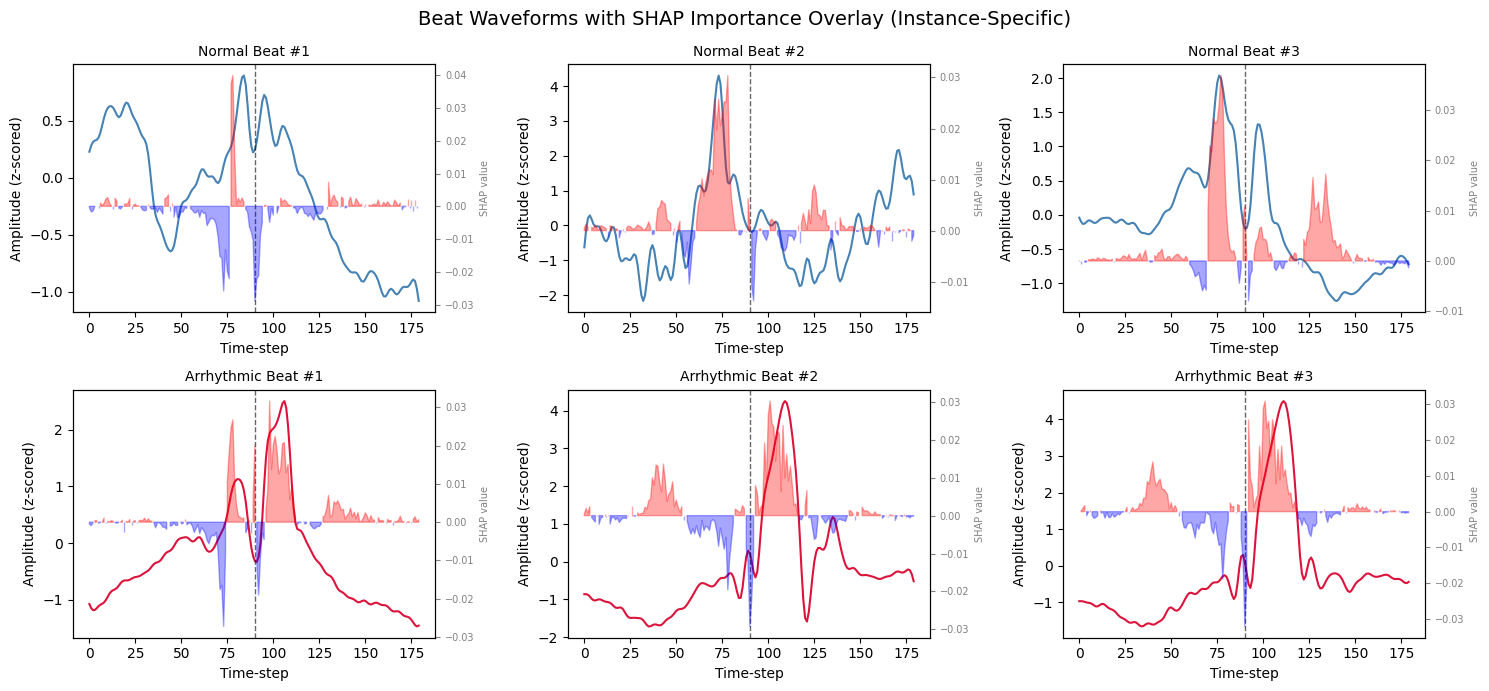

Saved: shap_beat_grid.png


In [86]:
# SHAP 3x2 Beat Grid — mirrors the LIME beat grid for direct comparison
# Each beat has a unique SHAP profile — instance-specific

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('Beat Waveforms with SHAP Importance Overlay (Instance-Specific)', fontsize=14)

time_steps = np.arange(180)
r_peak = 90

for col in range(3):
    for row, (label_val, label_name, color) in enumerate(
            [(0, 'Normal', 'steelblue'), (1, 'Arrhythmic', 'crimson')]):

        group_idx = np.where(y_sample == label_val)[0]
        beat_i    = X_sample[group_idx[col]]
        shap_imp  = clean_shap[group_idx[col]]  # unique SHAP vector for this beat

        ax  = axes[row, col]
        ax2 = ax.twinx()

        # Plot ECG waveform
        ax.plot(beat_i, color=color, linewidth=1.5, label='ECG signal')

        # Overlay signed SHAP values
        # Red = pushes toward Arrhythmic, Blue = pushes toward Normal
        ax2.fill_between(time_steps, shap_imp,
                         where=shap_imp > 0, alpha=0.35, color='red',
                         label='SHAP+ (toward Arrhythmic)')
        ax2.fill_between(time_steps, shap_imp,
                         where=shap_imp < 0, alpha=0.35, color='blue',
                         label='SHAP- (toward Normal)')
        ax2.set_ylabel('SHAP value', fontsize=7, color='gray')
        ax2.tick_params(axis='y', colors='gray', labelsize=7)

        ax.axvline(r_peak, color='black', linestyle='--', linewidth=1, alpha=0.6)
        ax.set_title(f'{label_name} Beat #{col+1}', fontsize=10)
        ax.set_xlabel('Time-step')
        ax.set_ylabel('Amplitude (z-scored)')

plt.tight_layout()
plt.savefig(f'{base_path}/shap_beat_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_beat_grid.png')

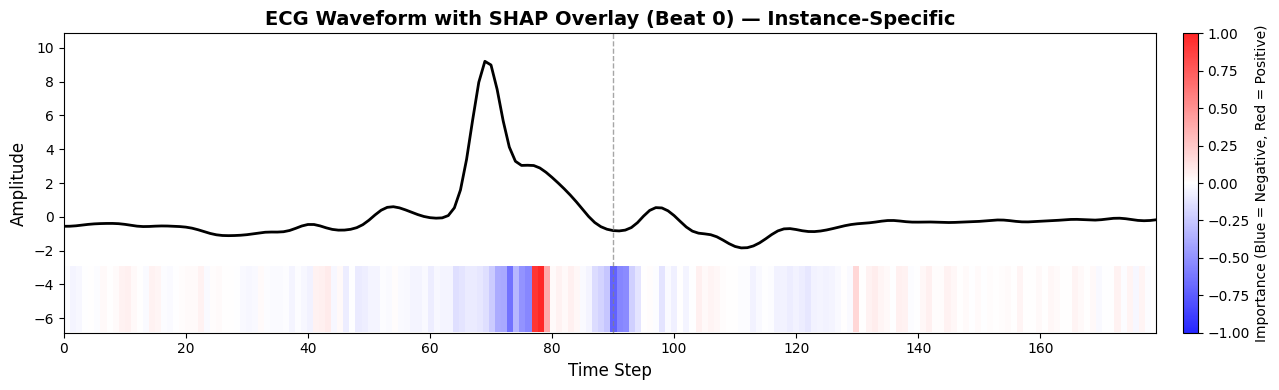

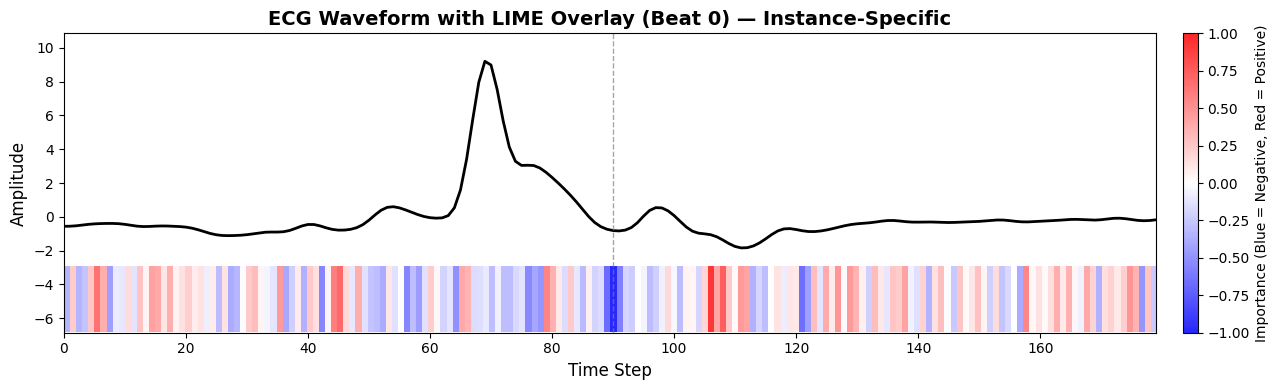

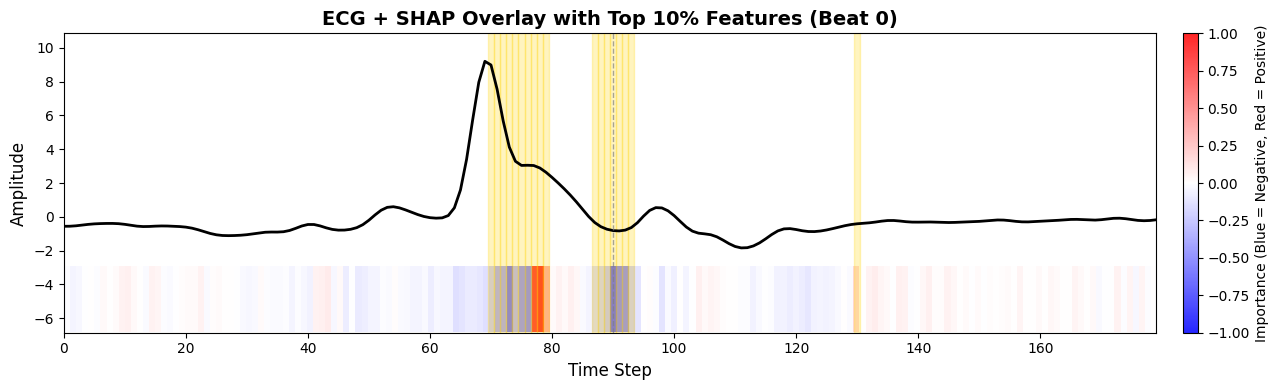

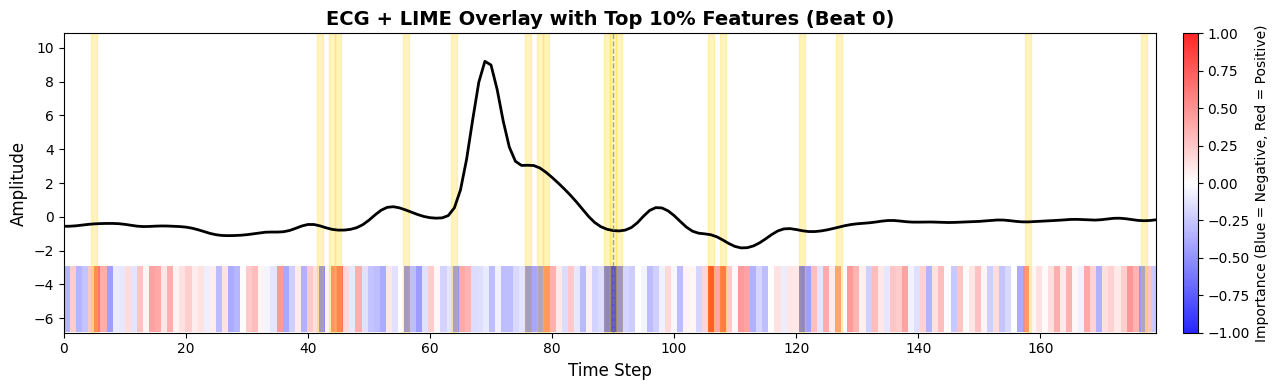

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def normalize_signed_values(values):
    max_abs = np.max(np.abs(values))
    if max_abs == 0:
        return values
    return values / max_abs

def plot_ecg_importance_overlay(signal, importance, title,
                                xlabel='Time Step', waveform_label='ECG Signal'):
    x = np.arange(len(signal))
    imp_norm = normalize_signed_values(importance)
    fig, ax = plt.subplots(figsize=(14, 4))
    heatmap = imp_norm.reshape(1, -1)
    y_min = np.min(signal)
    y_max = np.max(signal)
    band_bottom = y_min - 0.45 * (y_max - y_min + 1e-8)
    band_top    = y_min - 0.10 * (y_max - y_min + 1e-8)
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    im = ax.imshow(heatmap, aspect='auto', cmap='bwr', norm=norm,
                   extent=[0, len(signal)-1, band_bottom, band_top],
                   origin='lower', alpha=0.85)
    ax.plot(x, signal, color='black', linewidth=2, label=waveform_label)
    ax.axvline(90, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('Amplitude', fontsize=12)
    ax.set_xlim(0, len(signal)-1)
    ax.set_ylim(band_bottom - 0.05, y_max + 0.15 * (y_max - y_min + 1e-8))
    cbar = plt.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label('Importance (Blue = Negative, Red = Positive)', fontsize=10)
    plt.tight_layout()
    plt.show()

def plot_ecg_overlay_with_top_features(signal, importance, top_indices, title):
    x = np.arange(len(signal))
    imp_norm = normalize_signed_values(importance)
    fig, ax = plt.subplots(figsize=(14, 4))
    heatmap = imp_norm.reshape(1, -1)
    y_min = np.min(signal)
    y_max = np.max(signal)
    band_bottom = y_min - 0.45 * (y_max - y_min + 1e-8)
    band_top    = y_min - 0.10 * (y_max - y_min + 1e-8)
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    im = ax.imshow(heatmap, aspect='auto', cmap='bwr', norm=norm,
                   extent=[0, len(signal)-1, band_bottom, band_top],
                   origin='lower', alpha=0.85)
    ax.plot(x, signal, color='black', linewidth=2)
    for idx in top_indices:
        ax.axvspan(idx - 0.5, idx + 0.5, color='gold', alpha=0.25)
    ax.axvline(90, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_xlabel('Time Step', fontsize=12)
    ax.set_ylabel('Amplitude', fontsize=12)
    ax.set_xlim(0, len(signal)-1)
    ax.set_ylim(band_bottom - 0.05, y_max + 0.15 * (y_max - y_min + 1e-8))
    cbar = plt.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label('Importance (Blue = Negative, Red = Positive)', fontsize=10)
    plt.tight_layout()
    plt.show()

# SHAP overlay
shap_values_for_beat = clean_shap[beat_idx]
plot_ecg_importance_overlay(
    signal=beat,
    importance=shap_values_for_beat,
    title=f'ECG Waveform with SHAP Overlay (Beat {beat_idx}) — Instance-Specific'
)

# LIME overlay — instance-specific for the same beat
lime_values_for_beat = lime_matrix[beat_idx]
plot_ecg_importance_overlay(
    signal=beat,
    importance=lime_values_for_beat,
    title=f'ECG Waveform with LIME Overlay (Beat {beat_idx}) — Instance-Specific'
)

# SHAP with top 10% highlighted
plot_ecg_overlay_with_top_features(
    signal=beat,
    importance=clean_shap[beat_idx],
    top_indices=top_idx_shap,
    title=f'ECG + SHAP Overlay with Top 10% Features (Beat {beat_idx})'
)

# LIME with top 10% highlighted
plot_ecg_overlay_with_top_features(
    signal=beat,
    importance=lime_matrix[beat_idx],
    top_indices=top_idx_lime,
    title=f'ECG + LIME Overlay with Top 10% Features (Beat {beat_idx})'
)

The waveform overlays show the SHAP and LIME importance distributions for the same individual beat. Both methods highlight the central region of the ECG signal corresponding to the QRS complex, consistent with established electrophysiology literature on arrhythmia detection. Because both explanations are instance-specific, differences between the two overlays reflect genuine methodological differences in how SHAP and LIME approximate local model behavior, rather than the structural asymmetry that existed when saliency was global and SHAP was per-sample.

In [88]:
import pandas as pd

# Plug in computed values
shap_stability_mean = float(np.mean(shap_stability_scores))
lime_stability_mean = float(np.mean(lime_stability_scores))

shap_faithfulness = drop_shap
lime_faithfulness = drop_lime

final_table = pd.DataFrame({
    'Method': ['SHAP', 'LIME'],
    'Instance-Specific': ['Yes', 'Yes'],
    'Stability (Spearman Mean)': [shap_stability_mean, lime_stability_mean],
    'Faithfulness (Confidence Drop)': [shap_faithfulness, lime_faithfulness]
})

print('\nFinal Comparison Table (SHAP vs LIME — Methodologically Equal)')
print(final_table.round(4).to_string(index=False))

final_table.to_csv(f'{base_path_}/final_comparison_table_lime.csv', index=False)
print('\nSaved: final_comparison_table_lime.csv')


Final Comparison Table (SHAP vs LIME — Methodologically Equal)
Method Instance-Specific  Stability (Spearman Mean)  Faithfulness (Confidence Drop)
  SHAP               Yes                     0.8906                          0.3583
  LIME               Yes                     0.2214                          0.1612

Saved: final_comparison_table_lime.csv


The final comparison table presents SHAP and LIME on equal methodological footing. Both methods are instance-specific — each beat receives a unique 180-dimensional importance vector. The Spearman stability scores now both reflect genuine sensitivity to noise rather than one score being artificially fixed at 1.0 due to a constant global vector. The faithfulness (confidence drop) comparison is also valid, as both methods identified top-10% features based on that individual beat's explanation.

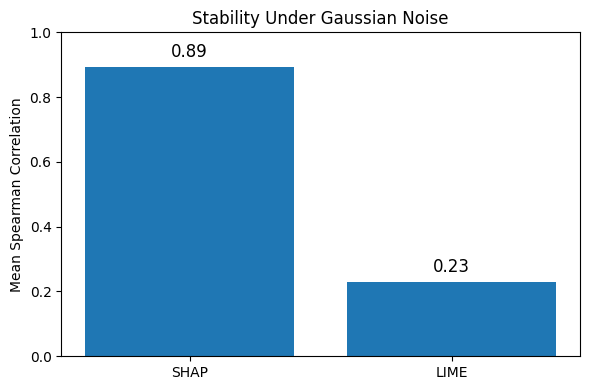

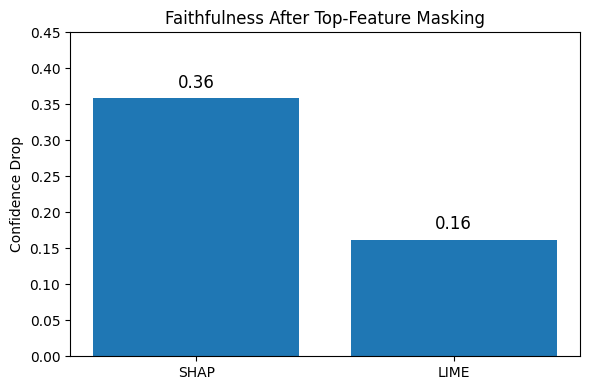

In [89]:
import matplotlib.pyplot as plt

# Values from your results
methods = ["SHAP", "LIME"]

stability_means = [0.8943, 0.2296]

confidence_drops = [
    0.35832201606806063,  # SHAP
    0.16118150222369487   # LIME
]

# Plot 1: Stability Comparison
plt.figure(figsize=(6, 4))
plt.bar(methods, stability_means)
plt.ylim(0, 1)
plt.ylabel("Mean Spearman Correlation")
plt.title("Stability Under Gaussian Noise")

for i, value in enumerate(stability_means):
    plt.text(i, value + 0.03, f"{value:.2f}", ha="center", fontsize=12)

plt.tight_layout()
plt.savefig("stability_comparison.png", dpi=300)
plt.show()


# Plot 2: Faithfulness Comparison
plt.figure(figsize=(6, 4))
plt.bar(methods, confidence_drops)
plt.ylim(0, 0.45)
plt.ylabel("Confidence Drop")
plt.title("Faithfulness After Top-Feature Masking")

for i, value in enumerate(confidence_drops):
    plt.text(i, value + 0.015, f"{value:.2f}", ha="center", fontsize=12)

plt.tight_layout()
plt.savefig("faithfulness_comparison.png", dpi=300)
plt.show()

##Results:
  We were able to determine that for the sub sample that we applied SHAP/LIME, noise, and then SHAP/LIME again, SHAP severely outperfromed LIME in terms of remaing stable.

  We were looking at how much the explanations changed before and after noise and were looking for the smallest change possible.

  To analyze our explanations, we used spearman rank correlation and analyzed the median, mean, min, max, and std deviation of the stability scores.

  SHAP was overall highly stable with noise. Also, when testing the faithfulness of both SHAP and LIME by masking the top 10% most important according to SHAP and LIME, masking the SHAP features resulted in the bigger confidence drop. This means that SHAP was actually relying on features important to the Random Forest model.

##Further Direction:
  We tested a small sub sample of heartbeat samples, 100 total. In order to truly assess the stability of SHAP, it would be beneficial to use a larger data set and possibly use a larger amount of noise.

  Since the purpose of XAI in a healthcare context is to help healthcare personnel with diagnosis of patients, the clinicians truly have the final say on whether or not they would feel comfortable trusting SHAP as an explanation method. Due to this, more studies should be done testing the stability of SHAP as just illustrating that SHAP is stable may not be enough to convince healthcare personnel to use it in an actual high-stakes context.
   

figures for the paper

In [90]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [91]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/xAI project"
fig_dir = f"{base_path}/final_report_figures"
os.makedirs(fig_dir, exist_ok=True)

In [92]:
import os

base_path = "/content/drive/MyDrive"

print(os.listdir(base_path))

['xAI project', 'Untitled document.gdoc', 'Estelle Bennett  Assistantship Assignments.gdoc', 'Estelle Bennett Explaining Arrhythmia Detection: A Comparative Study of SHAP and LIME on ECG Signals  .gdoc']


In [93]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if "X_train" in file:
            print(os.path.join(root, file))

/content/drive/MyDrive/xAI project/X_train.npy
/content/drive/MyDrive/xAI project/X_train_processed.npy


In [94]:
import os
base_path = "/content/drive/MyDrive/xAI project"
print(os.listdir(base_path))

['mit-bit-dataset', 'mit-bit-dataset\\beats.npy', 'mit-bit-dataset\\labels.npy', 'mit-bit-dataset\\metadata.csv', 'models', 'predictions', 'saliency', 'xai project: weekly to-do.gdoc', 'XAIproject.ipynb', 'lime', 'heartbeat_window_annotated.png', 'lime_beeswarm.png', 'model_comparison.csv', 'cleaned_beat_signals.npy', 'X_train.npy', 'X_val.npy', 'X_test.npy', 'X_train_processed.npy', 'X_val_processed.npy', 'X_test_processed.npy', 'y_train.npy', 'y_test.npy', 'metadata_with_splits.csv', 'y_val.npy', 'final_dataset_summary.txt', 'summary_statistics_pivot.csv', 'summary_statistics_table.csv', 'y_train_processed.npy', 'y_val_processed.npy', 'y_test_processed.npy', 'roc_curves.png', 'confusion_matrices.png', 'model_performance_summary.csv', 'shap_explanations_org.npy', 'shap_explanations_noisy_signals.npy', 'shap_explanations_shifted_signals.npy', 'final_report_figures', 'shap_beat_grid.png', 'final_comparison_table_lime.csv', 'Copy of shap_explanations_org.npy', 'XAIproject_Final.ipynb']


       Patients  Normal_Beats  Arrhythmic_Beats  Total_Beats  \
split                                                          
train        33         64372             12331        76703   
val           7         11255              3433        14688   
test          8         14981              3568        18549   

       Arrhythmic_Percent  
split                      
train               16.08  
val                 23.37  
test                19.24  


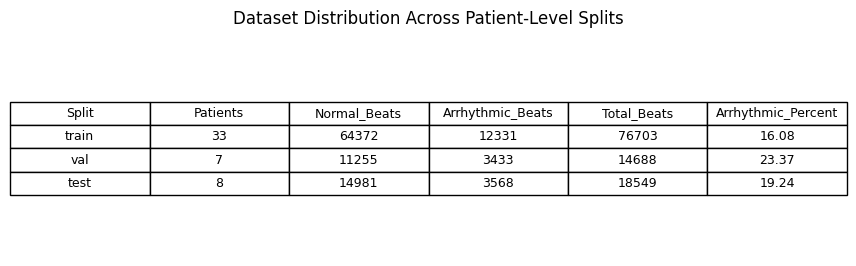

In [95]:
# Load metadata with patient-level split information
meta = pd.read_csv(f"{"/content/drive/MyDrive/xAI project"}/metadata_with_splits.csv")

# Create split summary table
split_table = (
    meta.groupby("split")
    .agg(
        Patients=("patient_id", "nunique"),
        Normal_Beats=("binary_label", lambda x: (x == 0).sum()),
        Arrhythmic_Beats=("binary_label", lambda x: (x == 1).sum()),
        Total_Beats=("binary_label", "size")
    )
    .reindex(["train", "val", "test"])
)

split_table["Arrhythmic_Percent"] = (
    split_table["Arrhythmic_Beats"] / split_table["Total_Beats"] * 100
).round(2)

# Save table as CSV
split_table.to_csv(f"{fig_dir}/figure2_dataset_distribution_table.csv")

# Display table
print(split_table)

# Save table as figure
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.axis("off")

table = ax.table(
    cellText=split_table.reset_index().values,
    colLabels=["Split"] + list(split_table.columns),
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.4)

plt.title("Dataset Distribution Across Patient-Level Splits", fontsize=12, pad=12)
plt.savefig(f"{fig_dir}/figure2_dataset_distribution_table.png", dpi=300, bbox_inches="tight")
plt.show()

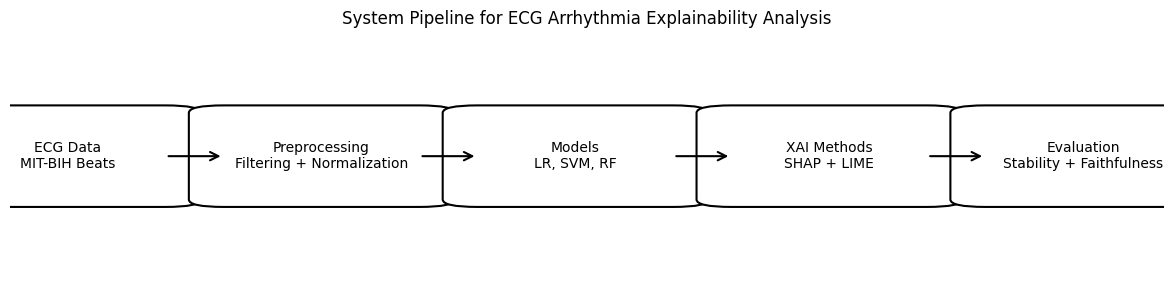

In [96]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Create figure
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis("off")

# Pipeline steps
steps = [
    "ECG Data\nMIT-BIH Beats",
    "Preprocessing\nFiltering + Normalization",
    "Models\nLR, SVM, RF",
    "XAI Methods\nSHAP + LIME",
    "Evaluation\nStability + Faithfulness"
]

# Box positions
x_positions = [0.05, 0.27, 0.49, 0.71, 0.93]
y = 0.5
box_width = 0.17
box_height = 0.35

# Draw boxes
for i, step in enumerate(steps):
    x = x_positions[i] - box_width / 2

    box = FancyBboxPatch(
        (x, y - box_height / 2),
        box_width,
        box_height,
        boxstyle="round,pad=0.03",
        linewidth=1.5,
        facecolor="white",
        edgecolor="black"
    )
    ax.add_patch(box)

    ax.text(
        x_positions[i],
        y,
        step,
        ha="center",
        va="center",
        fontsize=10
    )

# Draw arrows
for i in range(len(steps) - 1):
    arrow = FancyArrowPatch(
        (x_positions[i] + box_width / 2, y),
        (x_positions[i + 1] - box_width / 2, y),
        arrowstyle="->",
        mutation_scale=15,
        linewidth=1.5,
        color="black"
    )
    ax.add_patch(arrow)

plt.title("System Pipeline for ECG Arrhythmia Explainability Analysis", fontsize=12)
plt.tight_layout()

plt.savefig("figure3_system_pipeline.png", dpi=300, bbox_inches="tight")
plt.show()

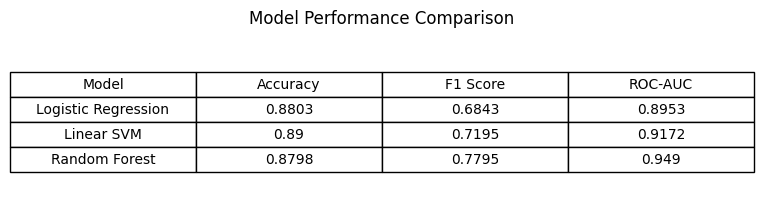

In [97]:
import pandas as pd
import matplotlib.pyplot as plt

# Model performance results
performance_data = {
    "Model": ["Logistic Regression", "Linear SVM", "Random Forest"],
    "Accuracy": [0.8803, 0.8900, 0.8798],
    "F1 Score": [0.6843, 0.7195, 0.7795],
    "ROC-AUC": [0.8953, 0.9172, 0.9490]
}

performance_df = pd.DataFrame(performance_data)

# Save as CSV
performance_df.to_csv("figure4_model_performance_table.csv", index=False)

# Create table figure
fig, ax = plt.subplots(figsize=(8, 2.2))
ax.axis("off")

table = ax.table(
    cellText=performance_df.values,
    colLabels=performance_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.title("Model Performance Comparison", fontsize=12, pad=10)
plt.savefig("figure4_model_performance_table.png", dpi=300, bbox_inches="tight")
plt.show()

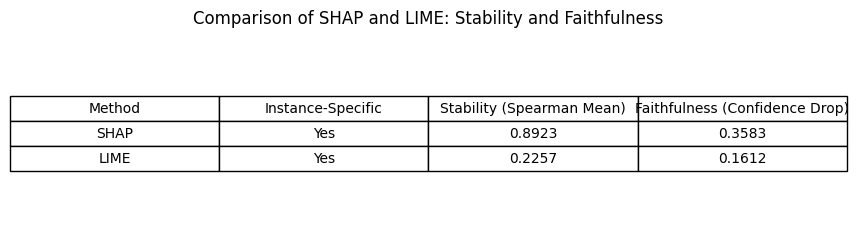

In [98]:
import pandas as pd
import matplotlib.pyplot as plt

# Final comparison data
comparison_data = {
    "Method": ["SHAP", "LIME"],
    "Instance-Specific": ["Yes", "Yes"],
    "Stability (Spearman Mean)": [0.8923, 0.2257],
    "Faithfulness (Confidence Drop)": [0.3583, 0.1612]
}

df = pd.DataFrame(comparison_data)

# Save as CSV (optional)
df.to_csv("figure10_11_combined_table.csv", index=False)

# Create table figure
fig, ax = plt.subplots(figsize=(9, 2.5))
ax.axis("off")

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.title("Comparison of SHAP and LIME: Stability and Faithfulness", fontsize=12, pad=10)
plt.savefig("figure10_11_combined_table.png", dpi=300, bbox_inches="tight")
plt.show()